# Notebook 04 — Análisis Exploratorio de Datos (EDA)

**Proyecto:** Sistema de Predicción y Clasificación de la Desnutrición en niños menores de cinco años  
**Fase CRISP-DM:** 2 — Entendimiento de los Datos  
**Dataset:** `113_limpio_unificado.csv` (generado por notebook 03)  
**Variable objetivo:** `clas_peso`

---
## Contenido
1. Carga y resumen general
2. Distribución de `clas_peso` (variable objetivo)
3. Análisis por edad
4. Análisis por sexo
5. Análisis temporal — evolución mensual
6. Análisis por municipio y departamento
7. Análisis socioeconómico (estrato y área)
8. Análisis étnico
9. Análisis de factores maternos e infantiles
10. Diagnóstico médico (CIE-10)
11. Correlación de variables
12. Pruebas de normalidad
13. Análisis ANOVA
14. Estadísticas descriptivas por clase de peso
15. Hallazgos y próximos pasos

## 1. Carga y resumen general

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy import stats
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

COLORES_CLASE = {
    'Desnut. severa'   : '#c0392b',
    'Desnut. moderada' : '#e67e22',
    'Normal bajo'      : '#f1c40f',
    'Normal'           : '#27ae60',
    'Sobrepeso'        : '#2980b9',
    'Obesidad'         : '#8e44ad',
}
ORDEN         = list(COLORES_CLASE.keys())
COLORES_LISTA = list(COLORES_CLASE.values())

MAPA_PESO = {1: 'Desnut. severa', 2: 'Desnut. moderada', 3: 'Normal bajo',
             4: 'Normal', 5: 'Sobrepeso', 6: 'Obesidad'}

In [2]:
df = pd.read_csv('../data/processed/113_limpio_unificado.csv')

# Eliminar el registro con fecha 2026 (error de digitación)
if 'anio_mes' in df.columns:
    df = df[df['anio_mes'] <= '2025-12'].copy()

# Eliminar los 9 nulos en clas_peso
df = df.dropna(subset=['clas_peso']).copy()
df['clas_peso'] = df['clas_peso'].astype(int)

# Variable objetivo y flag de desnutrición
df['clas_peso_label'] = df['clas_peso'].map(MAPA_PESO)
df['desnutrido']      = df['clas_peso'].isin([1, 2])

print(f'Registros totales : {len(df):,}')
print(f'Columnas          : {df.shape[1]}')
print(f'Años              : {sorted(df["anio"].unique())}')
print(f'Municipios únicos : {df["municipio_origen"].nunique()}')
print(f'Departamentos     : {df["depto_origen"].nunique()}')
print()
print('Nulos en columnas clave:')
cols_clave = ['clas_peso', 'peso_nac', 'talla_nac', 'edad_ges', 'peso_act',
              'talla_act', 'per_braqui', 'imc', 'zscore_pt', 'zscore_te',
              'estrato_', 'sexo_', 'per_etn_', 't_lechem', 'esq_vac', 'niv_educat']
cols_presentes = [c for c in cols_clave if c in df.columns]
nulos = df[cols_presentes].isnull().sum()
print(nulos[nulos > 0].rename('Nulos').to_string())
print()
print('Nota: talla_nac tiene ~61% de nulos — es normal en la ficha SIVIGILA,')
print('donde este dato no siempre se registra. No afecta el análisis principal.')

Registros totales : 2,438
Columnas          : 69
Años              : [np.int64(2023), np.int64(2024), np.int64(2025)]
Municipios únicos : 36
Departamentos     : 9

Nulos en columnas clave:
talla_nac     1502
per_braqui     227
niv_educat      33

Nota: talla_nac tiene ~61% de nulos — es normal en la ficha SIVIGILA,
donde este dato no siempre se registra. No afecta el análisis principal.


---
## 2. Distribución de `clas_peso` (variable objetivo)

**Interpretación:** Revela el fuerte desbalance del dataset — más del 85% son casos de desnutrición.  
Esto es esperado: los datos vienen de una IPS, los niños llegan precisamente porque están desnutridos.  
Este desbalance es crítico para el modelado: se requerirá **SMOTE** o `class_weight='balanced'`.

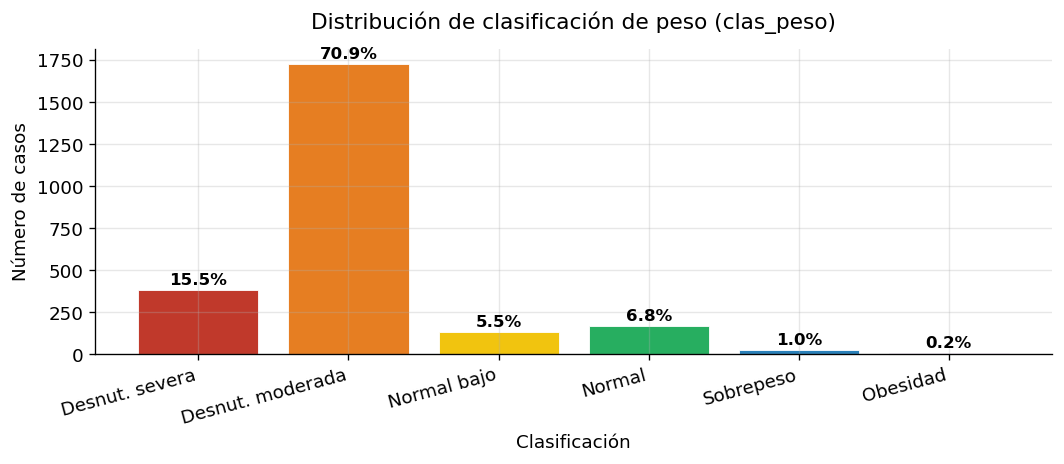

                  Casos  Porcentaje (%)
clas_peso_label                        
Desnut. severa      379           15.55
Desnut. moderada   1729           70.92
Normal bajo         133            5.46
Normal              167            6.85
Sobrepeso            24            0.98
Obesidad              6            0.25

Desbalance: 86.5% con algún tipo de desnutrición
Implicación para modelado: se requiere SMOTE o class_weight en los algoritmos.


In [3]:
conteo     = df['clas_peso_label'].value_counts().reindex(ORDEN)
porcentaje = conteo / conteo.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(ORDEN, conteo.values, color=COLORES_LISTA, edgecolor='white', linewidth=0.5)
for bar, pct in zip(bars, porcentaje.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Distribución de clasificación de peso (clas_peso)', fontsize=13, pad=12)
ax.set_xlabel('Clasificación')
ax.set_ylabel('Número de casos')
ax.set_xticklabels(ORDEN, rotation=15, ha='right')
plt.tight_layout()
plt.show()

resumen = pd.DataFrame({'Casos': conteo, 'Porcentaje (%)': porcentaje.round(2)})
print(resumen.to_string())
pct_desnut = porcentaje['Desnut. severa'] + porcentaje['Desnut. moderada']
print(f'\nDesbalance: {pct_desnut:.1f}% con algún tipo de desnutrición')
print('Implicación para modelado: se requiere SMOTE o class_weight en los algoritmos.')

---
## 3. Análisis por edad

**Interpretación:** Se analizan grupos etarios estándar OMS para menores de 5 años.  
El grupo 12-23 meses corresponde al destete y la transición alimentaria — etapa de mayor  
vulnerabilidad nutricional. Los outliers en el boxplot son casos reales, no errores.

In [4]:
df['edad_meses'] = df.apply(
    lambda r: r['edad_'] * 12 if r['uni_med_'] == 1 else r['edad_'], axis=1
)
bins   = [0, 5, 11, 23, 35, 47, 60]
labels = ['0-5m', '6-11m', '12-23m', '24-35m', '36-47m', '48-59m']
df['grupo_edad'] = pd.cut(df['edad_meses'], bins=bins, labels=labels, right=True)

ge     = df['grupo_edad'].value_counts().sort_index()
pct_ge = ge / ge.sum() * 100
print('Distribución por grupo etario (grupos OMS):')
print(pd.DataFrame({'Casos': ge, 'Porcentaje (%)': pct_ge.round(2)}).to_string())

Distribución por grupo etario (grupos OMS):
            Casos  Porcentaje (%)
grupo_edad                       
0-5m          182            7.47
6-11m         433           17.76
12-23m       1129           46.31
24-35m        372           15.26
36-47m        177            7.26
48-59m        145            5.95


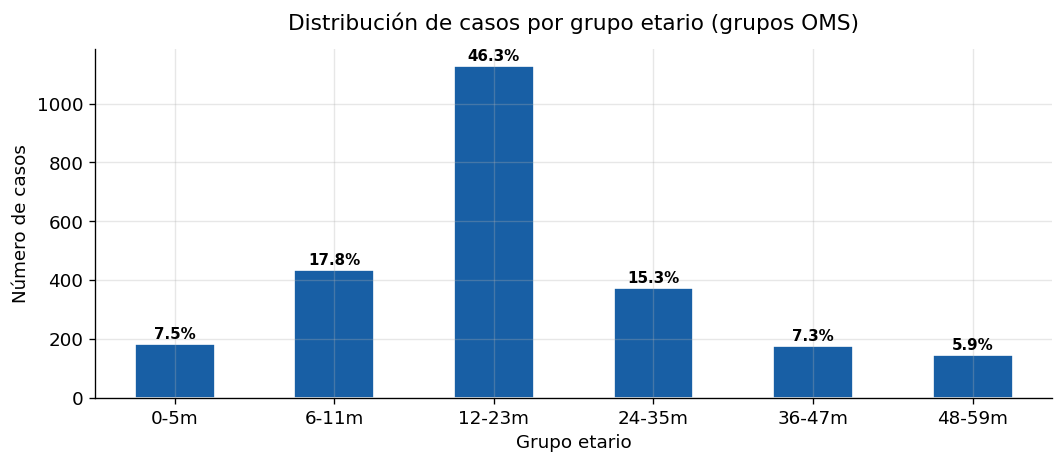

El grupo 12-23 meses concentra la mayor cantidad de casos.
Este período corresponde al destete y transición alimentaria, etapa de mayor riesgo nutricional.


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ge.plot(kind='bar', ax=ax, color='#185fa5', edgecolor='white')
for p, v in zip(ax.patches, pct_ge.values):
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 8,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Distribución de casos por grupo etario (grupos OMS)', fontsize=13, pad=12)
ax.set_xlabel('Grupo etario')
ax.set_ylabel('Número de casos')
ax.set_xticklabels(labels, rotation=0)
plt.tight_layout()
plt.show()
print('El grupo 12-23 meses concentra la mayor cantidad de casos.')
print('Este período corresponde al destete y transición alimentaria, etapa de mayor riesgo nutricional.')

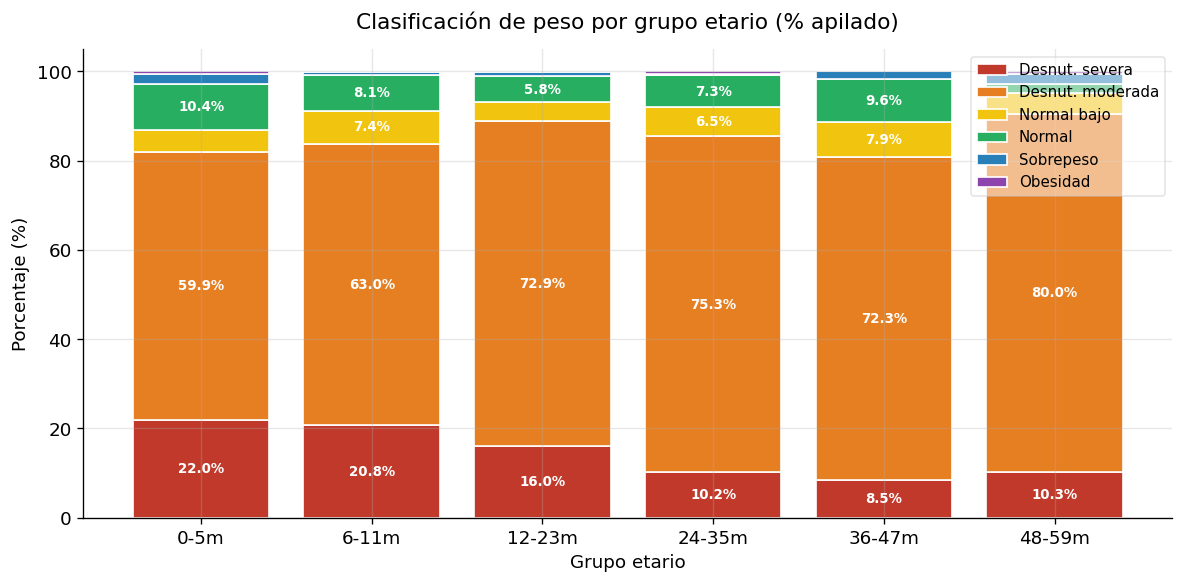

Tabla % de clas_peso por grupo etario:
clas_peso_label  Desnut. severa  Desnut. moderada  Normal bajo  Normal  Sobrepeso  Obesidad
grupo_edad                                                                                 
0-5m                      21.98             59.89         4.95   10.44       2.20      0.55
6-11m                     20.79             63.05         7.39    8.08       0.46      0.23
12-23m                    16.03             72.90         4.16    5.85       0.97      0.09
24-35m                    10.22             75.27         6.45    7.26       0.27      0.54
36-47m                     8.47             72.32         7.91    9.60       1.69      0.00
48-59m                    10.34             80.00         4.83    2.07       2.07      0.69


In [6]:
tabla_edad = pd.crosstab(df['grupo_edad'], df['clas_peso_label']).reindex(columns=ORDEN, fill_value=0)
tabla_pct  = tabla_edad.div(tabla_edad.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bottom  = np.zeros(len(tabla_pct))
for col, color in zip(ORDEN, COLORES_LISTA):
    vals = tabla_pct[col].values
    bars = ax.bar(tabla_pct.index.astype(str), vals, bottom=bottom,
                  color=color, edgecolor='white', label=col)
    for bar, v in zip(bars, vals):
        if v > 5:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                    f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals
ax.set_title('Clasificación de peso por grupo etario (% apilado)', fontsize=13, pad=12)
ax.set_xlabel('Grupo etario')
ax.set_ylabel('Porcentaje (%)')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', framealpha=0.5, fontsize=9)
plt.tight_layout()
plt.show()
print('Tabla % de clas_peso por grupo etario:')
print(tabla_pct.round(2).to_string())

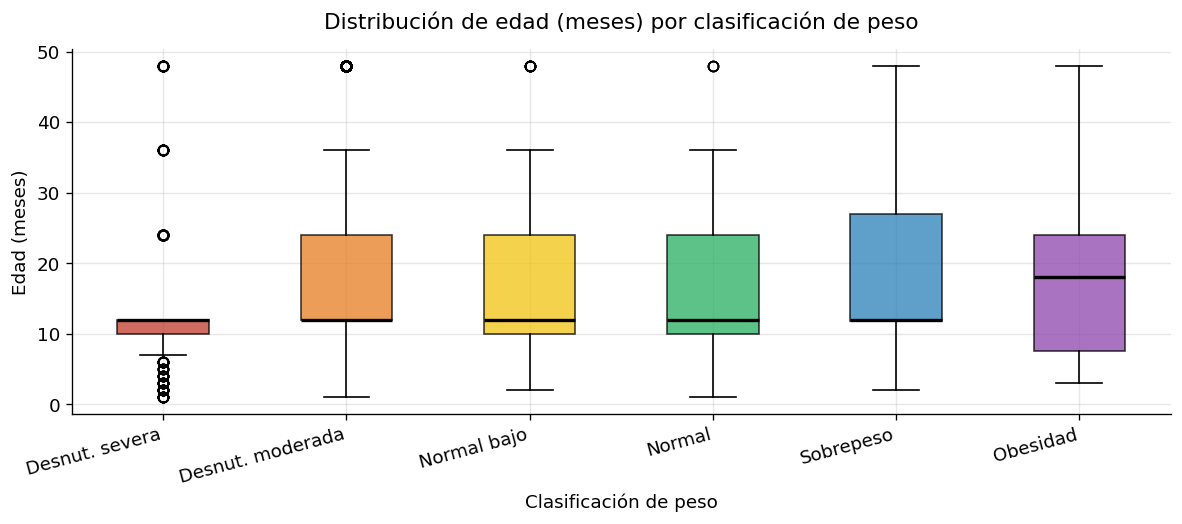

Mediana de edad (meses) por clase:
clas_peso_label
Desnut. severa      12.0
Desnut. moderada    12.0
Normal bajo         12.0
Normal              12.0
Sobrepeso           12.0
Obesidad            18.0

Las medianas similares en la mayoría de clases indican que la edad sola
no discrimina bien entre categorías de peso.


In [7]:
grupos_edad = [df.loc[df['clas_peso_label'] == c, 'edad_meses'].dropna().values for c in ORDEN]
fig, ax = plt.subplots(figsize=(10, 4.5))
bp = ax.boxplot(grupos_edad, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORES_LISTA):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticks(range(1, len(ORDEN) + 1))
ax.set_xticklabels(ORDEN, rotation=15, ha='right')
ax.set_title('Distribución de edad (meses) por clasificación de peso', fontsize=13, pad=12)
ax.set_xlabel('Clasificación de peso')
ax.set_ylabel('Edad (meses)')
plt.tight_layout()
plt.show()
print('Mediana de edad (meses) por clase:')
print(df.groupby('clas_peso_label')['edad_meses'].median().reindex(ORDEN).round(1).to_string())
print()
print('Las medianas similares en la mayoría de clases indican que la edad sola')
print('no discrimina bien entre categorías de peso.')

---
## 4. Análisis por sexo

**Interpretación:** Se usan tasas (porcentajes), no números absolutos,  
porque hay más niños que niñas en el dataset.  
Comparar valores absolutos entre grupos de distinto tamaño es estadísticamente incorrecto.

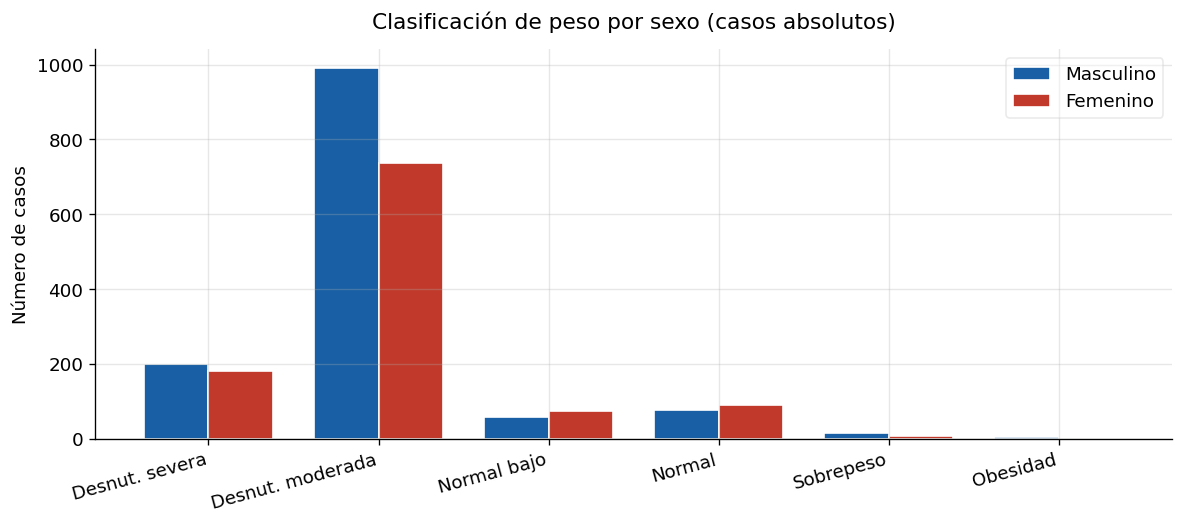

Tabla absoluta:
sexo_               F    M
clas_peso_label           
Desnut. severa    180  199
Desnut. moderada  737  992
Normal bajo        74   59
Normal             91   76
Sobrepeso           8   16
Obesidad            0    6

Tabla porcentual (base = total de cada sexo):
sexo_                 F      M
clas_peso_label               
Desnut. severa    16.51  14.76
Desnut. moderada  67.61  73.59
Normal bajo        6.79   4.38
Normal             8.35   5.64
Sobrepeso          0.73   1.19
Obesidad           0.00   0.45


In [8]:
tabla_sexo     = pd.crosstab(df['clas_peso_label'], df['sexo_']).reindex(ORDEN)
tabla_sexo_pct = tabla_sexo.div(tabla_sexo.sum(axis=0), axis=1) * 100

x, width = np.arange(len(ORDEN)), 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width/2, tabla_sexo.get('M', 0), width, label='Masculino', color='#185fa5', edgecolor='white')
ax.bar(x + width/2, tabla_sexo.get('F', 0), width, label='Femenino',  color='#c0392b', edgecolor='white')
ax.set_title('Clasificación de peso por sexo (casos absolutos)', fontsize=13, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(ORDEN, rotation=15, ha='right')
ax.set_ylabel('Número de casos')
ax.legend(framealpha=0.4)
plt.tight_layout()
plt.show()
print('Tabla absoluta:')
print(tabla_sexo.to_string())
print('\nTabla porcentual (base = total de cada sexo):')
print(tabla_sexo_pct.round(2).to_string())

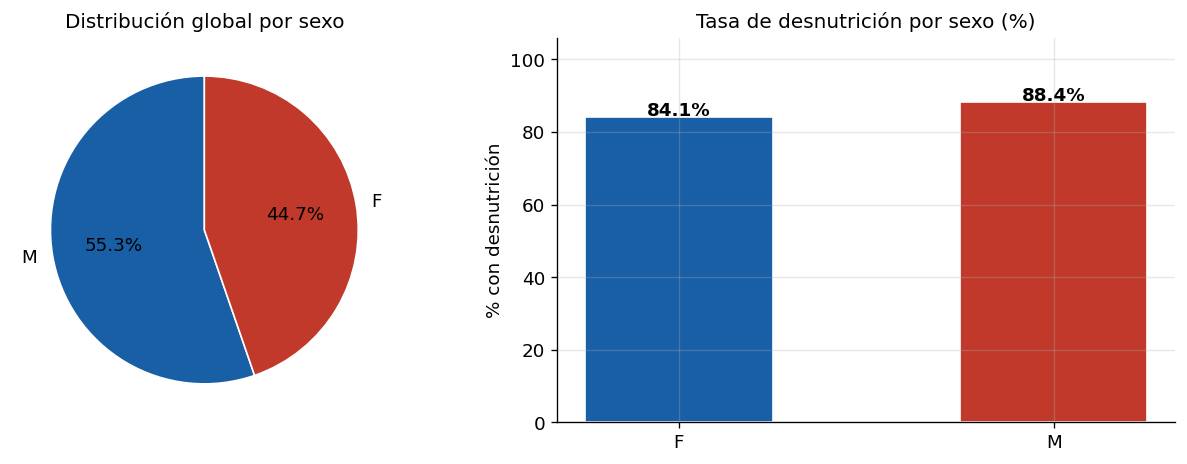

In [9]:
sexo_conteo      = df['sexo_'].value_counts()
tasa_desnut_sexo = df.groupby('sexo_')['desnutrido'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].pie(sexo_conteo.values, labels=sexo_conteo.index,
            autopct='%1.1f%%', colors=['#185fa5', '#c0392b'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[0].set_title('Distribución global por sexo', fontsize=12)

axes[1].bar(tasa_desnut_sexo.index, tasa_desnut_sexo.values,
            color=['#185fa5', '#c0392b'], edgecolor='white', width=0.5)
for i, (idx, val) in enumerate(tasa_desnut_sexo.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Tasa de desnutrición por sexo (%)', fontsize=12)
axes[1].set_ylabel('% con desnutrición')
axes[1].set_ylim(0, tasa_desnut_sexo.max() * 1.2)
plt.tight_layout()
plt.show()

---
## 5. Análisis temporal — evolución mensual

**Interpretación:** Se analiza la evolución de la tasa de desnutrición mes a mes.  
El año 2023 tiene pocos registros por mes (captura parcial), por lo que las tasas  
son inestables. El análisis de tendencia es válido principalmente desde 2024.  
La tasa sostenida ~85% indica que la situación no mejoró entre 2024 y 2025.

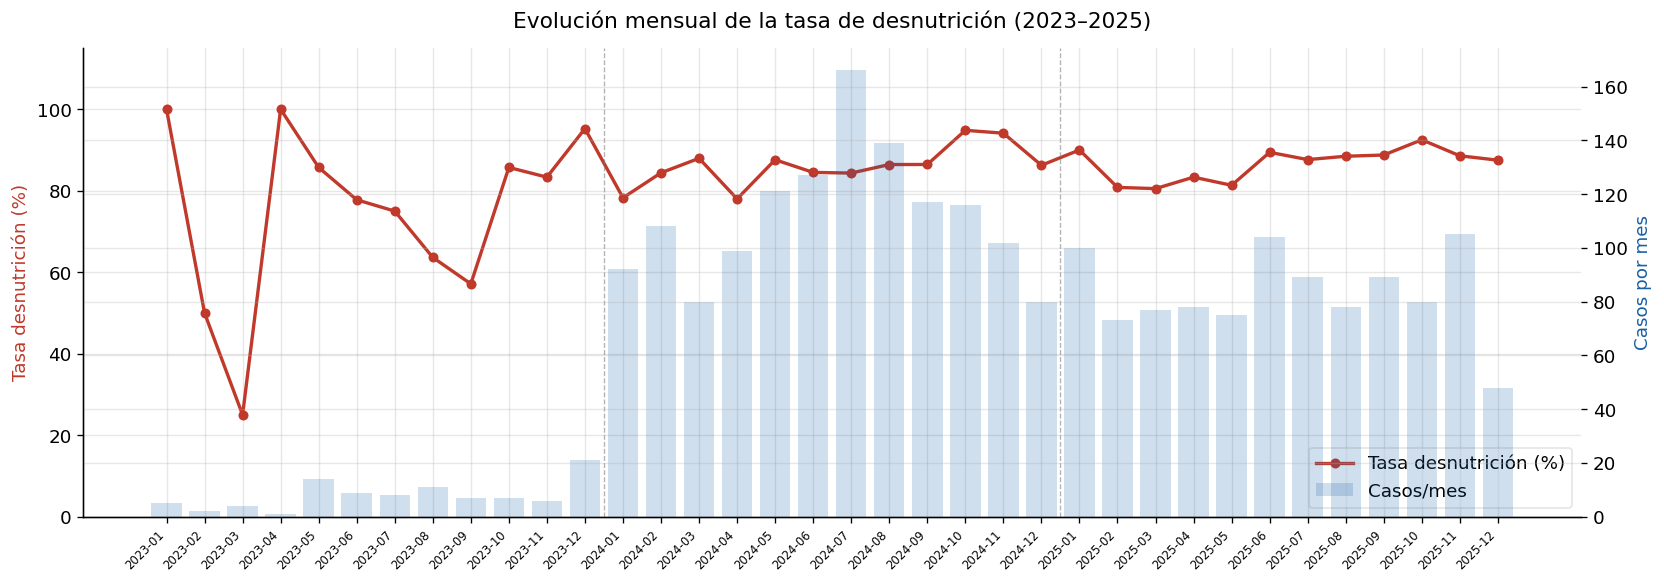

Estadísticas de la serie temporal (2023-2025):
anio_mes  casos  tasa_desnut  zscore_pt_media
 2023-01      5   100.000000        -2.898860
 2023-02      2    50.000000         0.180800
 2023-03      4    25.000000        -1.478650
 2023-04      1   100.000000        -2.601800
 2023-05     14    85.714286        -2.501943
 2023-06      9    77.777778        -1.849656
 2023-07      8    75.000000        -2.573787
 2023-08     11    63.636364        -1.942709
 2023-09      7    57.142857        -1.348986
 2023-10      7    85.714286        -2.235629
 2023-11      6    83.333333        -2.260333
 2023-12     21    95.238095        -2.462357
 2024-01     92    78.260870        -2.238415
 2024-02    108    84.403670        -2.305013
 2024-03     80    87.951807        -2.329905
 2024-04     99    78.000000        -2.137327
 2024-05    121    87.603306        -2.399207
 2024-06    127    84.496124        -2.325587
 2024-07    166    84.337349        -2.356880
 2024-08    139    86.428571     

In [10]:
# Cargar serie temporal (excluir el punto 2026-01 con 1 solo registro)
st = pd.read_csv('../data/processed/serie_temporal_mensual.csv')
st = st[st['anio_mes'] <= '2025-12'].copy()
st['fecha'] = pd.to_datetime(st['anio_mes'])

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Barras: número de casos por mes
ax2.bar(range(len(st)), st['casos'], color='#185fa5', alpha=0.2, label='Casos/mes')

# Línea: tasa de desnutrición
ax1.plot(range(len(st)), st['tasa_desnut'], 'o-', color='#c0392b',
         linewidth=2, markersize=5, label='Tasa desnutrición (%)')

# Separadores de año
for yr_start in [12, 24]:
    ax1.axvline(yr_start - 0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

ax1.set_xticks(range(len(st)))
ax1.set_xticklabels(st['anio_mes'], rotation=45, ha='right', fontsize=7)
ax1.set_ylabel('Tasa desnutrición (%)', color='#c0392b')
ax2.set_ylabel('Casos por mes', color='#185fa5')
ax1.set_title('Evolución mensual de la tasa de desnutrición (2023–2025)', fontsize=13, pad=12)
ax1.set_ylim(0, 115)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', framealpha=0.5)
plt.tight_layout()
plt.show()

print('Estadísticas de la serie temporal (2023-2025):')
print(st[['anio_mes','casos','tasa_desnut','zscore_pt_media']].to_string(index=False))

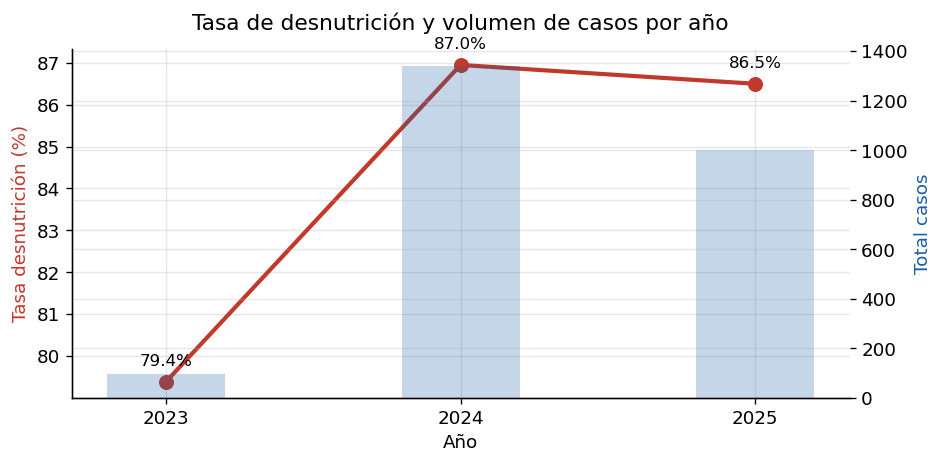

Total de casos por año:
anio
2023      97
2024    1341
2025    1000

Tasa de desnutrición por año (%):
anio
2023    79.38
2024    86.95
2025    86.50

Nota: 2023 solo tiene 97 registros — posible captura parcial del año.
La tasa sostenida ~85% en 2024 y 2025 indica que la situación no mejoró.


In [11]:
# Evolución anual comparativa
anios = sorted(df['anio'].unique())
tasa_anio  = df.groupby('anio')['desnutrido'].mean() * 100
total_anio = df.groupby('anio').size()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(tasa_anio.index, tasa_anio.values, 'o-', color='#c0392b', linewidth=2.5, markersize=8)
for x_val, y_val in zip(tasa_anio.index, tasa_anio.values):
    ax1.annotate(f'{y_val:.1f}%', (x_val, y_val),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)
ax2.bar(total_anio.index, total_anio.values, color='#185fa5', alpha=0.25, width=0.4)
ax1.set_title('Tasa de desnutrición y volumen de casos por año', fontsize=13, pad=12)
ax1.set_xlabel('Año')
ax1.set_ylabel('Tasa desnutrición (%)', color='#c0392b')
ax2.set_ylabel('Total casos', color='#185fa5')
ax1.set_xticks(anios)
plt.tight_layout()
plt.show()
print('Total de casos por año:')
print(total_anio.to_string())
print('\nTasa de desnutrición por año (%):')
print(tasa_anio.round(2).to_string())
print()
print('Nota: 2023 solo tiene 97 registros — posible captura parcial del año.')
print('La tasa sostenida ~85% en 2024 y 2025 indica que la situación no mejoró.')

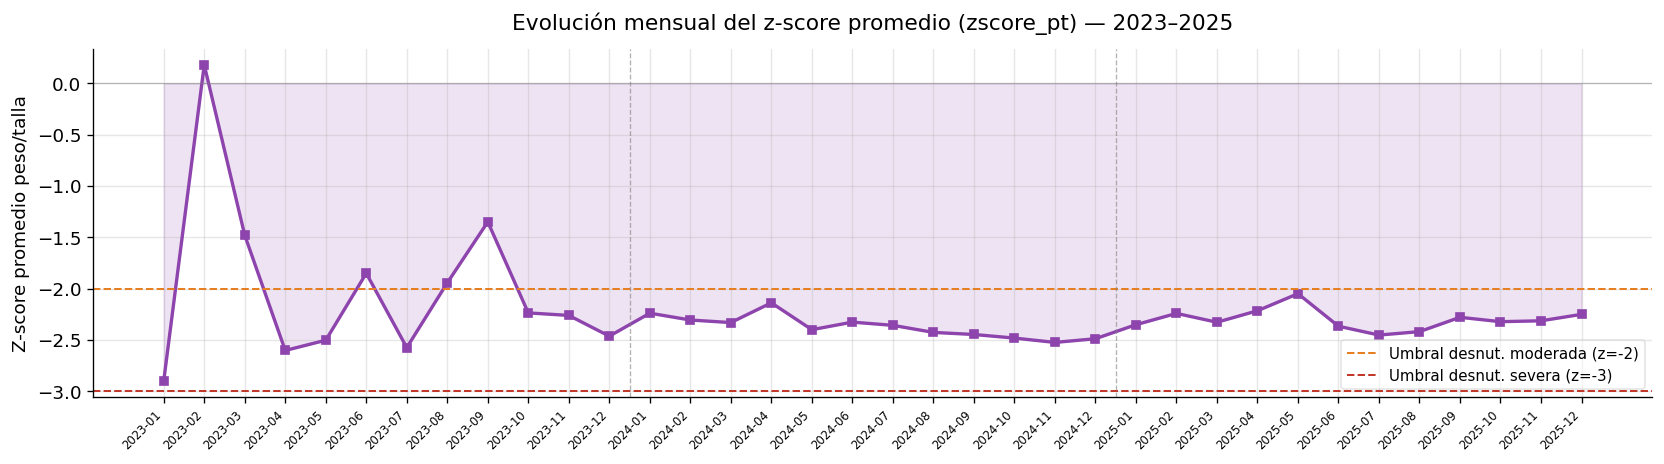

El zscore_pt promedio mensual se mantiene constantemente entre -2 y -2.5,
indicando desnutrición moderada sostenida como tendencia central de la población atendida.


In [12]:
# Evolución del zscore_pt promedio mensual (indicador continuo de severidad)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(len(st)), st['zscore_pt_media'], 's-', color='#8e44ad',
        linewidth=2, markersize=5)
ax.fill_between(range(len(st)), st['zscore_pt_media'], alpha=0.15, color='#8e44ad')
ax.axhline(-2, color='#e67e22', linestyle='--', linewidth=1.2, label='Umbral desnut. moderada (z=-2)')
ax.axhline(-3, color='#c0392b', linestyle='--', linewidth=1.2, label='Umbral desnut. severa (z=-3)')
ax.axhline(0, color='gray', linestyle='-', linewidth=0.7, alpha=0.5)
for yr_start in [12, 24]:
    ax.axvline(yr_start - 0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xticks(range(len(st)))
ax.set_xticklabels(st['anio_mes'], rotation=45, ha='right', fontsize=7)
ax.set_title('Evolución mensual del z-score promedio (zscore_pt) — 2023–2025', fontsize=13, pad=12)
ax.set_ylabel('Z-score promedio peso/talla')
ax.legend(fontsize=9, framealpha=0.5)
plt.tight_layout()
plt.show()
print('El zscore_pt promedio mensual se mantiene constantemente entre -2 y -2.5,')
print('indicando desnutrición moderada sostenida como tendencia central de la población atendida.')

---
## 6. Análisis por municipio y departamento

**Interpretación:** Se filtran municipios con menos de 20 casos para que las tasas sean  
estadísticamente representativas. Con pocos casos, una tasa del 100% no es informativa.

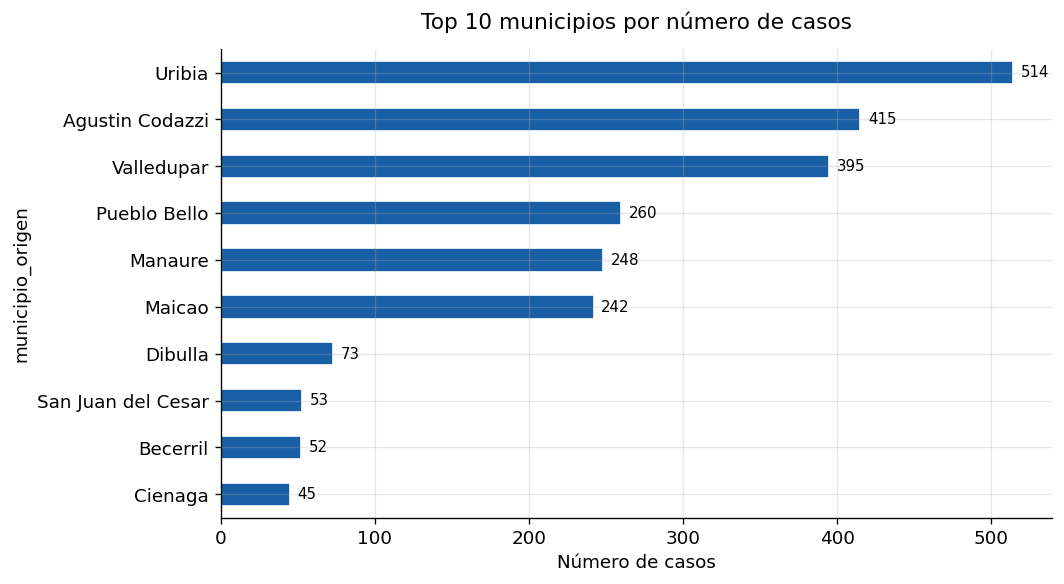

Valledupar concentra el mayor volumen por ser la capital del Cesar.
Uribia y Manaure (La Guajira) tienen alto volumen asociado a población Wayuu.


In [13]:
top10_mun = df['municipio_origen'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 5))
top10_mun[::-1].plot(kind='barh', ax=ax, color='#185fa5', edgecolor='white')
for p in ax.patches:
    ax.text(p.get_width() + 5, p.get_y() + p.get_height() / 2,
            f'{int(p.get_width()):,}', va='center', fontsize=9)
ax.set_title('Top 10 municipios por número de casos', fontsize=13, pad=12)
ax.set_xlabel('Número de casos')
plt.tight_layout()
plt.show()
print('Valledupar concentra el mayor volumen por ser la capital del Cesar.')
print('Uribia y Manaure (La Guajira) tienen alto volumen asociado a población Wayuu.')

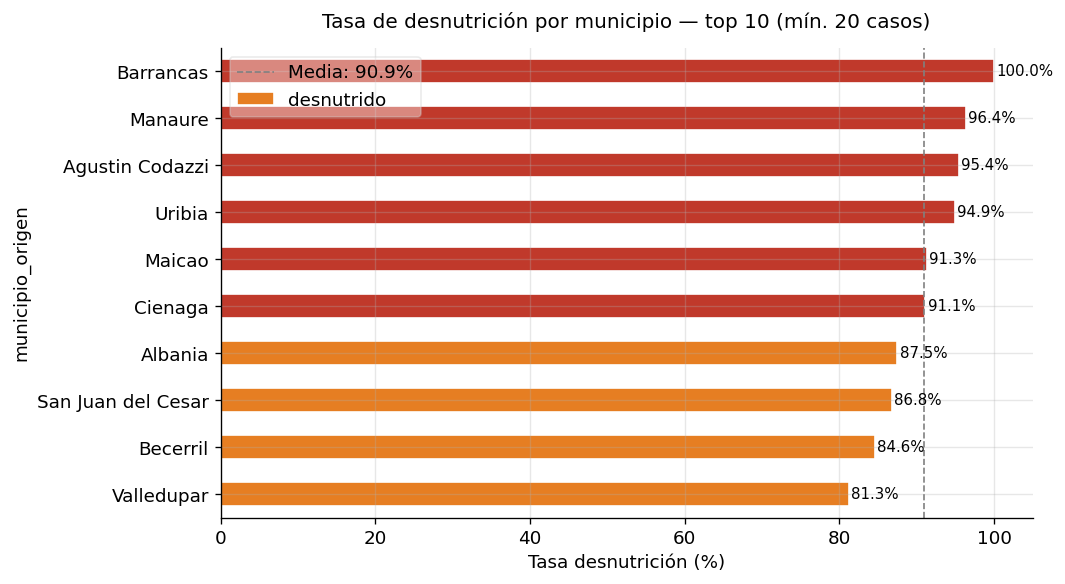

Tasa de desnutrición (%) — top 10 municipios:
municipio_origen
Barrancas             100.00
Manaure                96.37
Agustin Codazzi        95.42
Uribia                 94.94
Maicao                 91.32
Cienaga                91.11
Albania                87.50
San Juan del Cesar     86.79
Becerril               84.62
Valledupar             81.27


In [14]:
MIN_CASOS   = 20
conteo_mun  = df.groupby('municipio_origen').size()
mun_validos = conteo_mun[conteo_mun >= MIN_CASOS].index

tasa_mun = (df[df['municipio_origen'].isin(mun_validos)]
            .groupby('municipio_origen')['desnutrido']
            .mean().mul(100).sort_values(ascending=False))
tasa_mun_top10 = tasa_mun.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
colores_bar = ['#c0392b' if v >= tasa_mun_top10.mean() else '#e67e22' for v in tasa_mun_top10.values]
tasa_mun_top10[::-1].plot(kind='barh', ax=ax, color=colores_bar[::-1], edgecolor='white')
for p in ax.patches:
    ax.text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2,
            f'{p.get_width():.1f}%', va='center', fontsize=9)
ax.axvline(tasa_mun_top10.mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Media: {tasa_mun_top10.mean():.1f}%')
ax.set_title('Tasa de desnutrición por municipio — top 10 (mín. 20 casos)', fontsize=12, pad=12)
ax.set_xlabel('Tasa desnutrición (%)')
ax.legend(framealpha=0.4)
plt.tight_layout()
plt.show()
print('Tasa de desnutrición (%) — top 10 municipios:')
print(tasa_mun_top10.round(2).to_string())

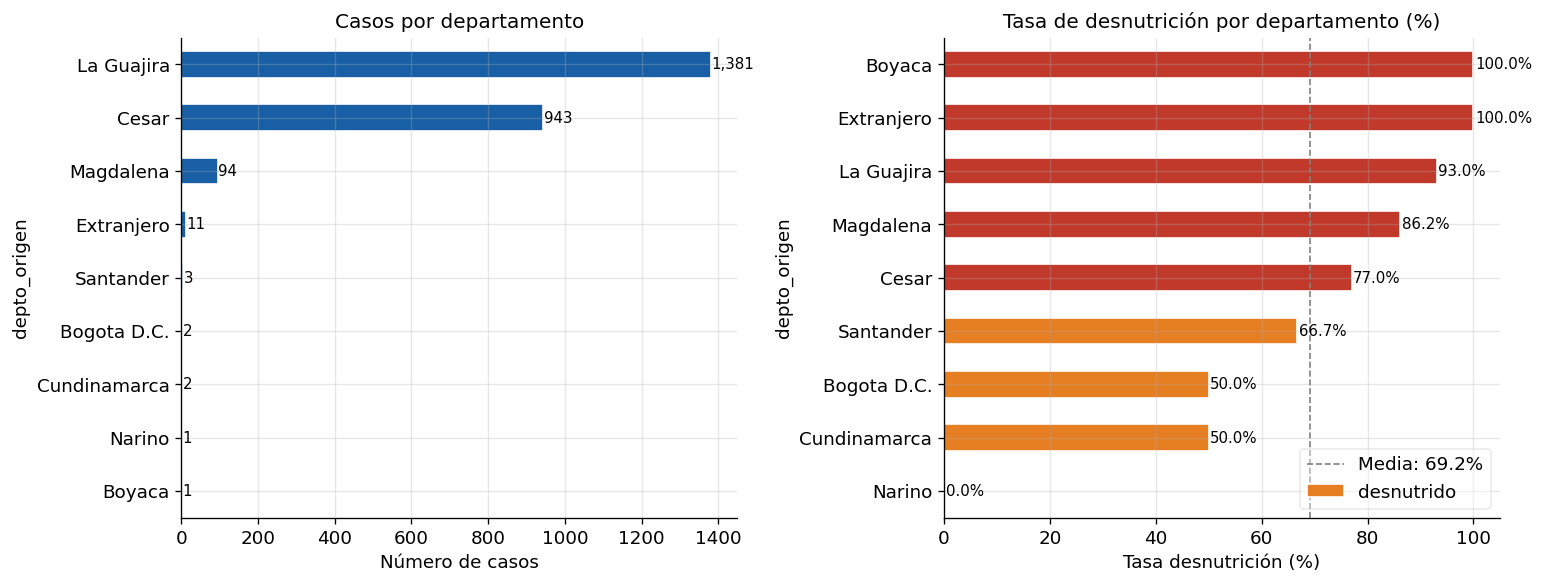

La Guajira históricamente presenta tasas más altas asociadas a la crisis nutricional Wayuu.


In [15]:
if 'depto_origen' in df.columns:
    conteo_dpto = df['depto_origen'].value_counts()
    tasa_dpto   = df.groupby('depto_origen')['desnutrido'].mean().mul(100).sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    conteo_dpto[::-1].plot(kind='barh', ax=axes[0], color='#185fa5', edgecolor='white')
    for p in axes[0].patches:
        axes[0].text(p.get_width() + 2, p.get_y() + p.get_height() / 2,
                     f'{int(p.get_width()):,}', va='center', fontsize=9)
    axes[0].set_title('Casos por departamento', fontsize=12)
    axes[0].set_xlabel('Número de casos')

    colores_dpto = ['#c0392b' if v >= tasa_dpto.mean() else '#e67e22' for v in tasa_dpto.values]
    tasa_dpto[::-1].plot(kind='barh', ax=axes[1], color=colores_dpto[::-1], edgecolor='white')
    for p in axes[1].patches:
        axes[1].text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2,
                     f'{p.get_width():.1f}%', va='center', fontsize=9)
    axes[1].axvline(tasa_dpto.mean(), color='gray', linestyle='--', linewidth=1,
                    label=f'Media: {tasa_dpto.mean():.1f}%')
    axes[1].set_title('Tasa de desnutrición por departamento (%)', fontsize=12)
    axes[1].set_xlabel('Tasa desnutrición (%)')
    axes[1].legend(framealpha=0.4)
    plt.tight_layout()
    plt.show()
    print('La Guajira históricamente presenta tasas más altas asociadas a la crisis nutricional Wayuu.')

---
## 7. Análisis socioeconómico — estrato y área

**Interpretación:** El estrato es una proxy del nivel de ingresos en Colombia (1=bajo, 6=alto).  
Se espera una relación **inversamente proporcional**: a mayor estrato, menor desnutrición.  
El área (cabecera / centro poblado / rural disperso) refleja el acceso a servicios de salud.

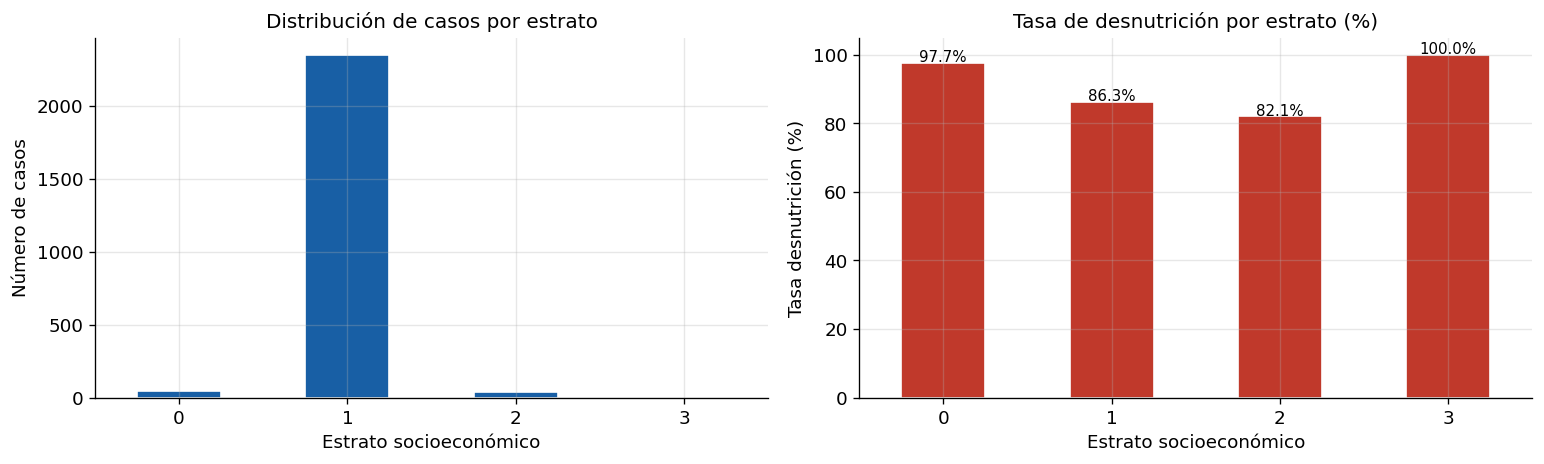

          Casos  Tasa desnutrición (%)
estrato_                              
0            44                  97.73
1          2352                  86.31
2            39                  82.05
3             3                 100.00

Correlación Pearson estrato_ vs clas_peso: 0.0318


In [16]:
if 'estrato_' in df.columns:
    conteo_estrato = df['estrato_'].value_counts().sort_index()
    tasa_estrato   = df.groupby('estrato_')['desnutrido'].mean().mul(100)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    conteo_estrato.plot(kind='bar', ax=axes[0], color='#185fa5', edgecolor='white')
    axes[0].set_title('Distribución de casos por estrato', fontsize=12)
    axes[0].set_xlabel('Estrato socioeconómico')
    axes[0].set_ylabel('Número de casos')
    axes[0].tick_params(axis='x', rotation=0)

    tasa_estrato.plot(kind='bar', ax=axes[1], color='#c0392b', edgecolor='white')
    for p in axes[1].patches:
        axes[1].text(p.get_x() + p.get_width() / 2, p.get_height() + 0.3,
                     f'{p.get_height():.1f}%', ha='center', fontsize=9)
    axes[1].set_title('Tasa de desnutrición por estrato (%)', fontsize=12)
    axes[1].set_xlabel('Estrato socioeconómico')
    axes[1].set_ylabel('Tasa desnutrición (%)')
    axes[1].tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

    print(pd.DataFrame({'Casos': conteo_estrato, 'Tasa desnutrición (%)': tasa_estrato.round(2)}).to_string())
    corr_estrato = df[['estrato_', 'clas_peso']].corr().iloc[0, 1]
    print(f'\nCorrelación Pearson estrato_ vs clas_peso: {corr_estrato:.4f}')

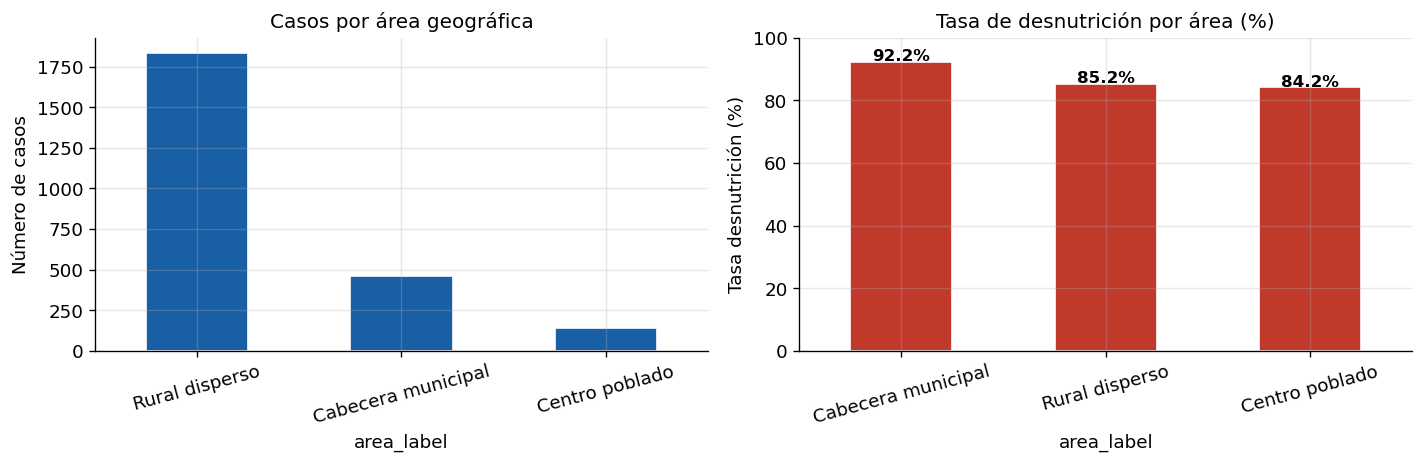

Tasa de desnutrición por área:
area_label
Cabecera municipal    92.21
Rural disperso        85.19
Centro poblado        84.17

El 75% de los casos proviene de zona rural dispersa,
donde el acceso a servicios de salud es más limitado (cobertura ~30%).


In [17]:
# Análisis por área (cabecera / centro poblado / rural)
mapa_area = {1: 'Cabecera municipal', 2: 'Centro poblado', 3: 'Rural disperso'}
df['area_label'] = df['area_'].map(mapa_area)

conteo_area = df['area_label'].value_counts()
tasa_area   = df.groupby('area_label')['desnutrido'].mean().mul(100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
conteo_area.plot(kind='bar', ax=axes[0], color='#185fa5', edgecolor='white')
axes[0].set_title('Casos por área geográfica', fontsize=12)
axes[0].set_ylabel('Número de casos')
axes[0].tick_params(axis='x', rotation=15)

tasa_area.plot(kind='bar', ax=axes[1], color='#c0392b', edgecolor='white')
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width() / 2, p.get_height() + 0.3,
                 f'{p.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Tasa de desnutrición por área (%)', fontsize=12)
axes[1].set_ylabel('Tasa desnutrición (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()
print('Tasa de desnutrición por área:')
print(tasa_area.round(2).to_string())
print()
print('El 75% de los casos proviene de zona rural dispersa,')
print('donde el acceso a servicios de salud es más limitado (cobertura ~30%).')

---
## 8. Análisis étnico

**Interpretación:** Comunidades indígenas como los Wayuu enfrentan factores estructurales  
como acceso limitado a agua potable, servicios de salud y seguridad alimentaria,  
lo que eleva sus tasas de desnutrición.

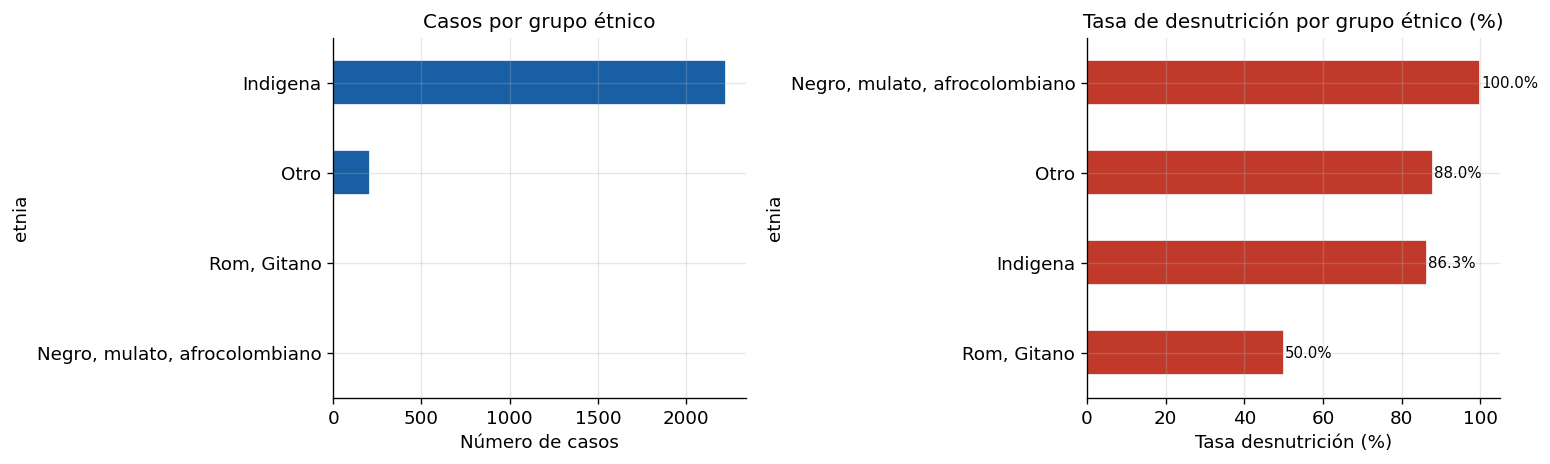

Tasa de desnutrición por grupo étnico (%):
etnia
Negro, mulato, afrocolombiano    100.00
Otro                              87.98
Indigena                          86.35
Rom, Gitano                       50.00


In [18]:
col_etnia = 'etnia' if 'etnia' in df.columns else 'per_etn_'

conteo_etnia = df[col_etnia].value_counts()
tasa_etnia   = df.groupby(col_etnia)['desnutrido'].mean().mul(100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conteo_etnia[::-1].plot(kind='barh', ax=axes[0], color='#185fa5', edgecolor='white')
axes[0].set_title('Casos por grupo étnico', fontsize=12)
axes[0].set_xlabel('Número de casos')

tasa_etnia[::-1].plot(kind='barh', ax=axes[1], color='#c0392b', edgecolor='white')
for p in axes[1].patches:
    axes[1].text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2,
                 f'{p.get_width():.1f}%', va='center', fontsize=9)
axes[1].set_title('Tasa de desnutrición por grupo étnico (%)', fontsize=12)
axes[1].set_xlabel('Tasa desnutrición (%)')
plt.tight_layout()
plt.show()

print('Tasa de desnutrición por grupo étnico (%):')
print(tasa_etnia.round(2).to_string())

---
## 9. Análisis de factores maternos e infantiles

Variables disponibles gracias al dataset completo (no estaban en el CSV anterior):
- `t_lechem` — tiempo de lactancia materna (meses)
- `e_complem` — edad de inicio de alimentación complementaria (meses)
- `crec_dllo` — seguimiento en crecimiento y desarrollo (1=Con, 2=Sin)
- `esq_vac` — esquema de vacunación (1=Completo, 2=Incompleto, 3=Sin esquema)
- `niv_educat` — nivel educativo de la madre
- `menores` — número de menores en el hogar

**Nota sobre `niv_educat`:** El código 5 ('Superior') concentra 1,170 casos — más que
cualquier otro nivel. En la ficha SIVIGILA este código puede corresponder a 'Sin dato'
en algunos formularios. Se muestra el análisis pero debe interpretarse con cautela.

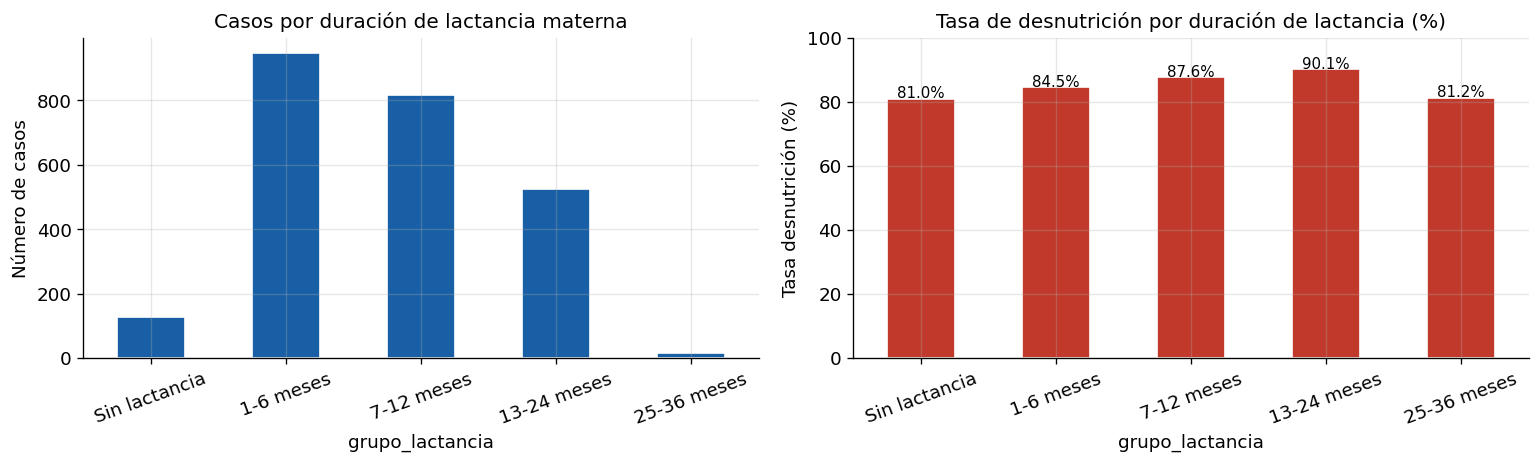

Casos excluidos por outlier t_lechem > 36 meses: 10
                 Casos  Tasa desnut (%)
grupo_lactancia                        
Sin lactancia      126            80.95
1-6 meses          947            84.48
7-12 meses         816            87.62
13-24 meses        523            90.06
25-36 meses         16            81.25


In [19]:
# ── Lactancia materna ─────────────────────────────────────────────────────
# Excluir outliers > 36 meses (biológicamente improbable)
df_lec = df[df['t_lechem'] <= 36].copy()
df_lec['grupo_lactancia'] = pd.cut(df_lec['t_lechem'],
    bins=[-1, 0, 6, 12, 24, 36],
    labels=['Sin lactancia', '1-6 meses', '7-12 meses', '13-24 meses', '25-36 meses'])

conteo_lec = df_lec['grupo_lactancia'].value_counts().sort_index()
tasa_lec   = df_lec.groupby('grupo_lactancia')['desnutrido'].mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conteo_lec.plot(kind='bar', ax=axes[0], color='#185fa5', edgecolor='white')
axes[0].set_title('Casos por duración de lactancia materna', fontsize=12)
axes[0].set_ylabel('Número de casos')
axes[0].tick_params(axis='x', rotation=20)

tasa_lec.plot(kind='bar', ax=axes[1], color='#c0392b', edgecolor='white')
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width() / 2, p.get_height() + 0.3,
                 f'{p.get_height():.1f}%', ha='center', fontsize=9)
axes[1].set_title('Tasa de desnutrición por duración de lactancia (%)', fontsize=12)
axes[1].set_ylabel('Tasa desnutrición (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
print('Casos excluidos por outlier t_lechem > 36 meses:', (df['t_lechem'] > 36).sum())
print(pd.DataFrame({'Casos': conteo_lec, 'Tasa desnut (%)': tasa_lec.round(2)}).to_string())

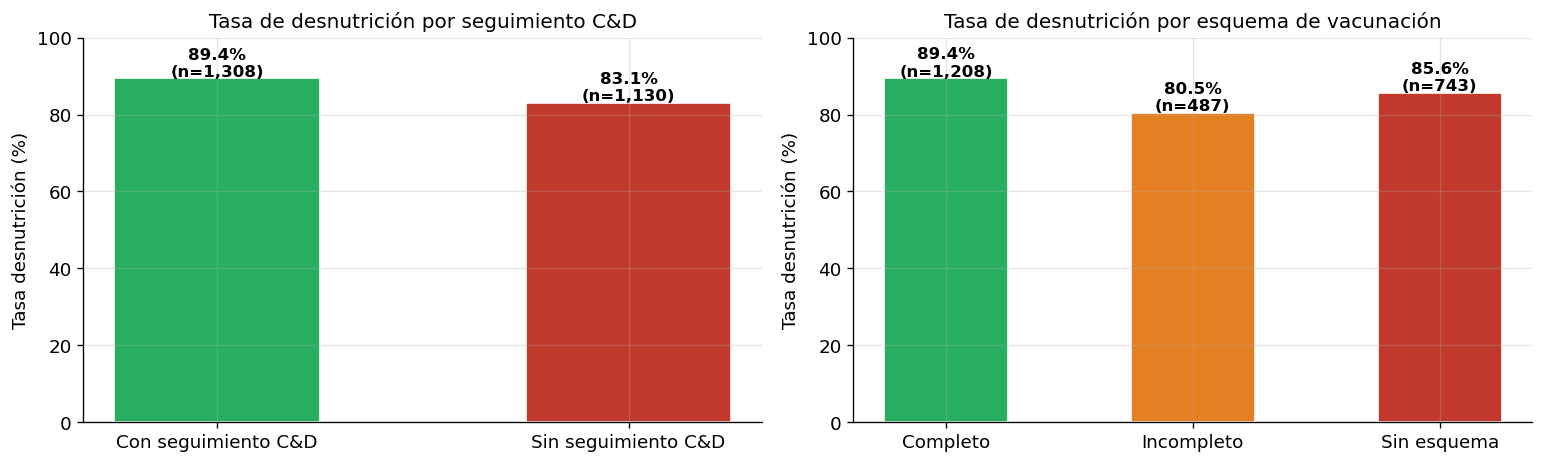

In [20]:
# ── Seguimiento crecimiento y desarrollo + vacunación ─────────────────────
mapa_crec  = {1: 'Con seguimiento C&D', 2: 'Sin seguimiento C&D'}
mapa_vac   = {1: 'Completo', 2: 'Incompleto', 3: 'Sin esquema'}
df['crec_label'] = df['crec_dllo'].map(mapa_crec)
df['vac_label']  = df['esq_vac'].map(mapa_vac)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Seguimiento C&D
tasa_crec   = df.groupby('crec_label')['desnutrido'].mean().mul(100)
conteo_crec = df['crec_label'].value_counts()
axes[0].bar(conteo_crec.index, tasa_crec[conteo_crec.index].values,
            color=['#27ae60', '#c0392b'], edgecolor='white', width=0.5)
for i, (idx, val) in enumerate(tasa_crec[conteo_crec.index].items()):
    axes[0].text(i, val + 0.5, f'{val:.1f}%\n(n={conteo_crec[idx]:,})',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Tasa de desnutrición por seguimiento C&D', fontsize=12)
axes[0].set_ylabel('Tasa desnutrición (%)')
axes[0].set_ylim(0, 100)

# Vacunación
orden_vac = ['Completo', 'Incompleto', 'Sin esquema']
tasa_vac  = df.groupby('vac_label')['desnutrido'].mean().mul(100).reindex(orden_vac)
conteo_vac = df['vac_label'].value_counts().reindex(orden_vac)
axes[1].bar(orden_vac, tasa_vac.values, color=['#27ae60', '#e67e22', '#c0392b'],
            edgecolor='white', width=0.5)
for i, (val, n) in enumerate(zip(tasa_vac.values, conteo_vac.values)):
    axes[1].text(i, val + 0.5, f'{val:.1f}%\n(n={n:,})',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Tasa de desnutrición por esquema de vacunación', fontsize=12)
axes[1].set_ylabel('Tasa desnutrición (%)')
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()

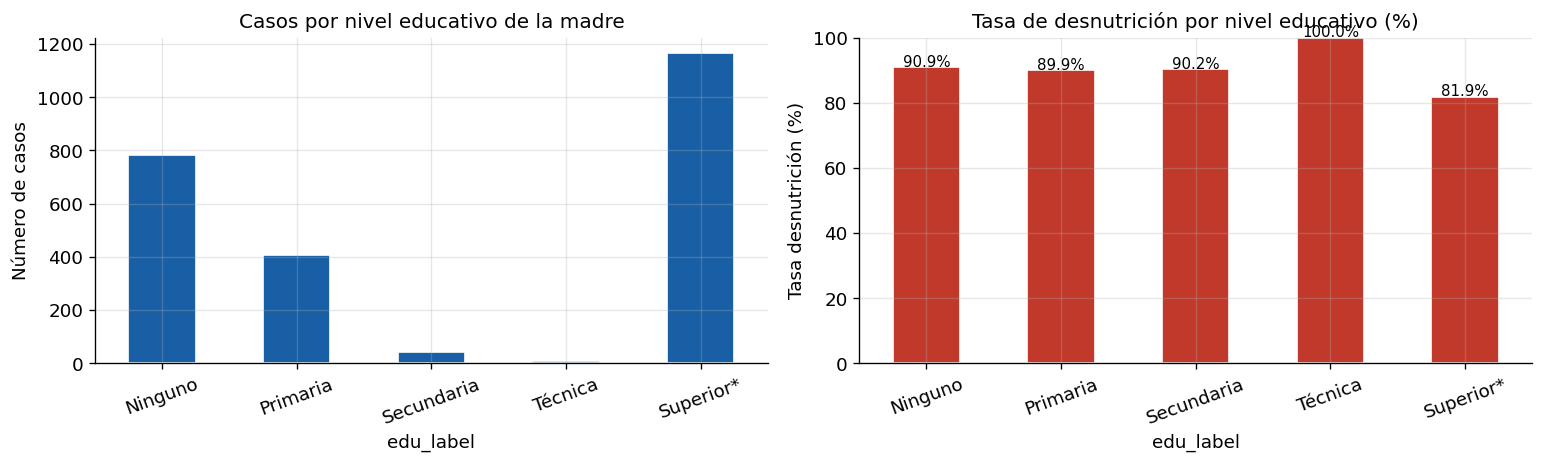

* Superior (código 5): puede corresponder a "Sin dato" en algunos formularios SIVIGILA.
  Interpretar con cautela.
            Casos  Tasa desnut (%)
edu_label                         
Ninguno       782            90.92
Primaria      406            89.90
Secundaria     41            90.24
Técnica        10           100.00
Superior*    1166            81.90


In [21]:
# ── Educación de la madre ─────────────────────────────────────────────────
mapa_edu = {1: 'Ninguno', 2: 'Primaria', 3: 'Secundaria', 4: 'Técnica', 5: 'Superior*'}
df['edu_label'] = df['niv_educat'].map(mapa_edu)

conteo_edu = df['edu_label'].value_counts().reindex(mapa_edu.values())
tasa_edu   = df.groupby('edu_label')['desnutrido'].mean().mul(100).reindex(mapa_edu.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conteo_edu.plot(kind='bar', ax=axes[0], color='#185fa5', edgecolor='white')
axes[0].set_title('Casos por nivel educativo de la madre', fontsize=12)
axes[0].set_ylabel('Número de casos')
axes[0].tick_params(axis='x', rotation=20)

tasa_edu.plot(kind='bar', ax=axes[1], color='#c0392b', edgecolor='white')
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width() / 2, p.get_height() + 0.3,
                 f'{p.get_height():.1f}%', ha='center', fontsize=9)
axes[1].set_title('Tasa de desnutrición por nivel educativo (%)', fontsize=12)
axes[1].set_ylabel('Tasa desnutrición (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
print('* Superior (código 5): puede corresponder a "Sin dato" en algunos formularios SIVIGILA.')
print('  Interpretar con cautela.')
print(pd.DataFrame({'Casos': conteo_edu, 'Tasa desnut (%)': tasa_edu.round(2)}).to_string())

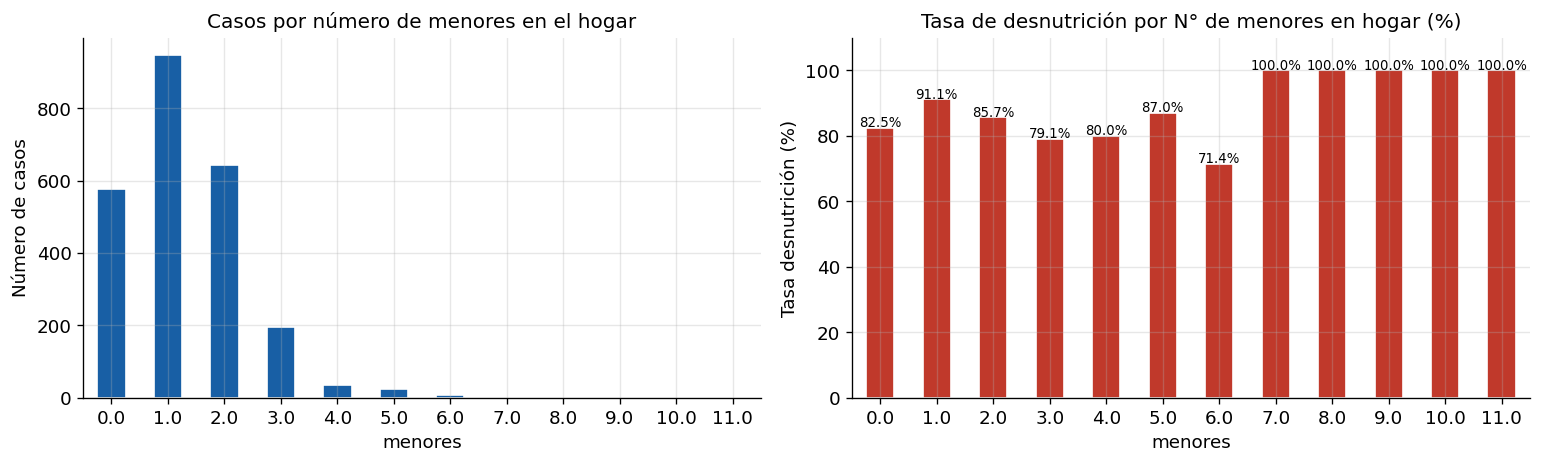

Correlación Pearson menores vs clas_peso: -0.0088
La tasa alta con 1 menor puede indicar que el niño enfermo recibe menos atención
cuando hay más hermanos compitiendo por recursos del hogar.


In [22]:
# ── Número de menores en el hogar ─────────────────────────────────────────
tasa_menores   = df.groupby('menores')['desnutrido'].mean().mul(100)
conteo_menores = df['menores'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conteo_menores.plot(kind='bar', ax=axes[0], color='#185fa5', edgecolor='white')
axes[0].set_title('Casos por número de menores en el hogar', fontsize=12)
axes[0].set_ylabel('Número de casos')
axes[0].tick_params(axis='x', rotation=0)

tasa_menores.plot(kind='bar', ax=axes[1], color='#c0392b', edgecolor='white')
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width() / 2, p.get_height() + 0.3,
                 f'{p.get_height():.1f}%', ha='center', fontsize=8)
axes[1].set_title('Tasa de desnutrición por N° de menores en hogar (%)', fontsize=12)
axes[1].set_ylabel('Tasa desnutrición (%)')
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
corr_men = df['menores'].corr(df['clas_peso'])
print(f'Correlación Pearson menores vs clas_peso: {corr_men:.4f}')
print('La tasa alta con 1 menor puede indicar que el niño enfermo recibe menos atención')
print('cuando hay más hermanos compitiendo por recursos del hogar.')

---
## 10. Diagnóstico médico (CIE-10)

**Interpretación:** El código diagnóstico confirma el tipo clínico de desnutrición registrado.  
Permite verificar la consistencia con `clas_peso` y entender la distribución clínica del dataset.

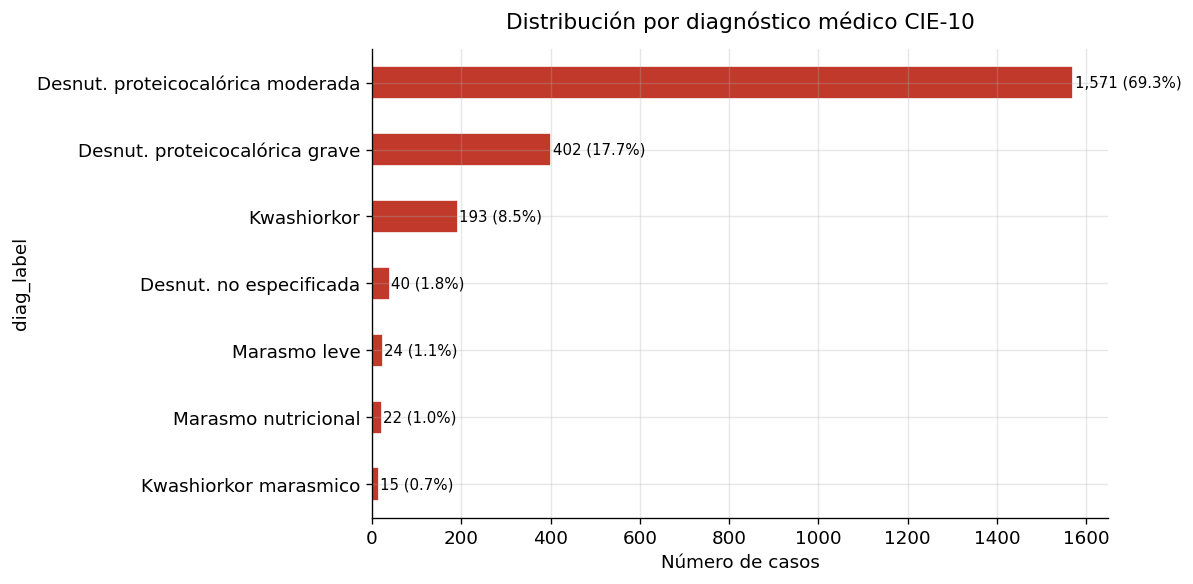

Distribución de diagnósticos:
  E440 — Desnut. proteicocalórica moderada: 1571 (64.4%)
  E43X — Desnut. proteicocalórica grave: 402 (16.5%)
  E40X — Kwashiorkor: 193 (7.9%)
  E46X — Desnut. no especificada: 40 (1.6%)
  E441 — Marasmo leve: 24 (1.0%)
  E41X — Marasmo nutricional: 22 (0.9%)
  E42X — Kwashiorkor marasmico: 15 (0.6%)


In [23]:
mapa_diag = {
    'E440': 'Desnut. proteicocalórica moderada',
    'E43X': 'Desnut. proteicocalórica grave',
    'E40X': 'Kwashiorkor',
    'E46X': 'Desnut. no especificada',
    'E441': 'Marasmo leve',
    'E41X': 'Marasmo nutricional',
    'E42X': 'Kwashiorkor marasmico',
}

df_diag = df[df['diag_medic'].isin(mapa_diag.keys())].copy()
df_diag['diag_label'] = df_diag['diag_medic'].map(mapa_diag)
conteo_diag = df_diag['diag_label'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
conteo_diag[::-1].plot(kind='barh', ax=ax, color='#c0392b', edgecolor='white')
for p in ax.patches:
    pct = p.get_width() / len(df_diag) * 100
    ax.text(p.get_width() + 3, p.get_y() + p.get_height() / 2,
            f'{int(p.get_width()):,} ({pct:.1f}%)', va='center', fontsize=9)
ax.set_title('Distribución por diagnóstico médico CIE-10', fontsize=13, pad=12)
ax.set_xlabel('Número de casos')
plt.tight_layout()
plt.show()
print('Distribución de diagnósticos:')
for cod, desc in mapa_diag.items():
    n = df['diag_medic'].eq(cod).sum()
    print(f'  {cod} — {desc}: {n} ({n/len(df)*100:.1f}%)')

---
## 11. Correlación de variables con `clas_peso`

**Importante — Data Leakage:**  
`zscore_pt` tiene r≈0.91 con `clas_peso` porque **son la misma información**:  
la Resolución 2465 de 2016 establece que `clas_peso` se calcula directamente  
a partir de `zscore_pt`. No es un hallazgo predictivo, es una tautología matemática.  
Lo mismo aplica a `imc` (r≈0.79) que entra en el cálculo del z-score.  
**Por esta razón `zscore_pt` e `zscore_te` fueron excluidos de `dataset_ml.csv`.**

Las correlaciones realmente útiles para el modelo son las variables que aparecen  
más abajo: `per_braqui`, `peso_act`, `area_`, `niv_educat`, variables clínicas observables.

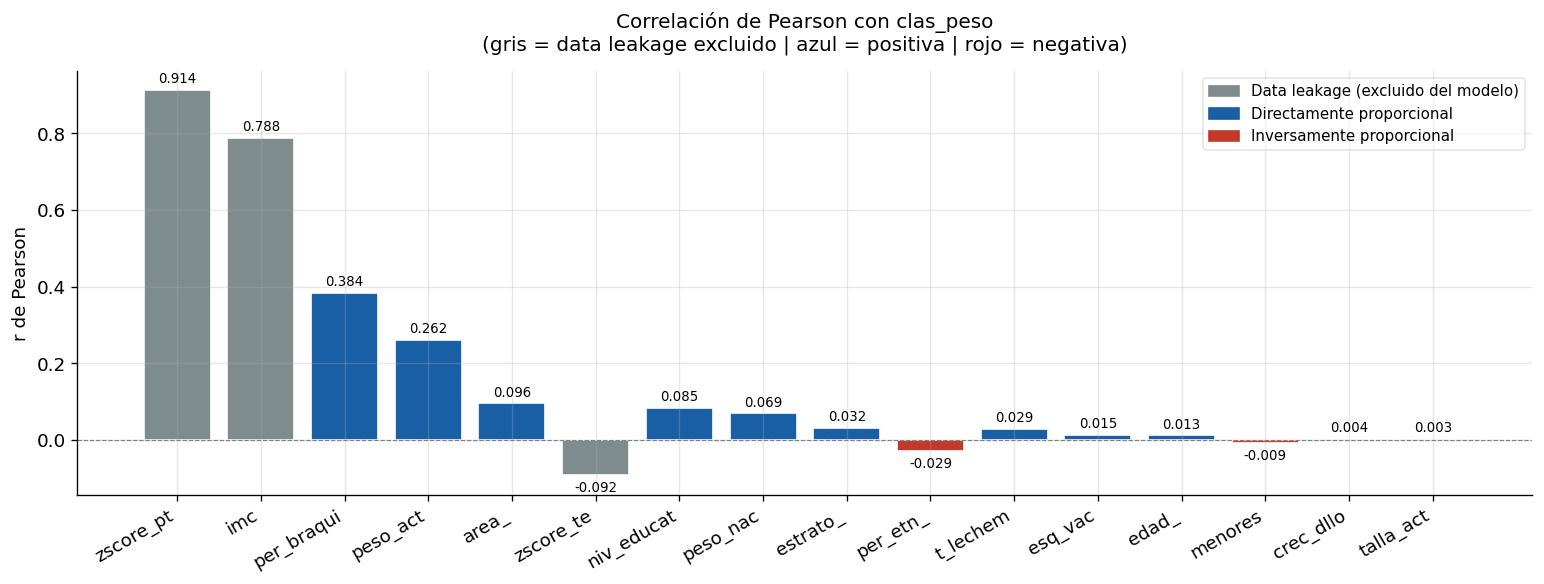

Variables SIN leakage — correlaciones con clas_peso:
per_braqui    0.3840
peso_act      0.2617
area_         0.0961
niv_educat    0.0846
peso_nac      0.0695
estrato_      0.0318
per_etn_     -0.0294
t_lechem      0.0291
esq_vac       0.0145
edad_         0.0126
menores      -0.0088
crec_dllo     0.0039
talla_act     0.0035


In [24]:
# Correlaciones incluyendo zscore para mostrar el leakage
cols_corr_todas = ['zscore_pt', 'imc', 'per_braqui', 'peso_act',
                   'peso_nac', 'zscore_te', 'edad_', 'talla_act',
                   'estrato_', 'per_etn_', 'area_',
                   't_lechem', 'niv_educat', 'menores', 'crec_dllo', 'esq_vac']
cols_corr_todas = [c for c in cols_corr_todas if c in df.columns]

corr_todas = (df[cols_corr_todas + ['clas_peso']]
              .corr()['clas_peso']
              .drop('clas_peso')
              .sort_values(key=abs, ascending=False))

# Colorear: rojo = leakage (zscore/imc), azul = positiva, naranja = negativa
def color_barra(col, val):
    if col in ['zscore_pt', 'zscore_te', 'imc']:
        return '#7f8c8d'   # gris = leakage, excluido del modelo
    return '#185fa5' if val >= 0 else '#c0392b'

colores_corr = [color_barra(col, val) for col, val in corr_todas.items()]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(corr_todas.index, corr_todas.values, color=colores_corr, edgecolor='white')
for bar, val in zip(bars, corr_todas.values):
    y = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.05
    ax.text(bar.get_x() + bar.get_width() / 2, y,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_title('Correlación de Pearson con clas_peso\n'
             '(gris = data leakage excluido | azul = positiva | rojo = negativa)',
             fontsize=12, pad=12)
ax.set_ylabel('r de Pearson')
ax.set_xticklabels(corr_todas.index, rotation=30, ha='right')

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [Patch(color='#7f8c8d', label='Data leakage (excluido del modelo)'),
           Patch(color='#185fa5', label='Directamente proporcional'),
           Patch(color='#c0392b', label='Inversamente proporcional')]
ax.legend(handles=leyenda, fontsize=9, framealpha=0.5)
plt.tight_layout()
plt.show()

print('Variables SIN leakage — correlaciones con clas_peso:')
corr_sin_leak = corr_todas[[c for c in corr_todas.index if c not in ['zscore_pt','zscore_te','imc']]]
print(corr_sin_leak.round(4).to_string())

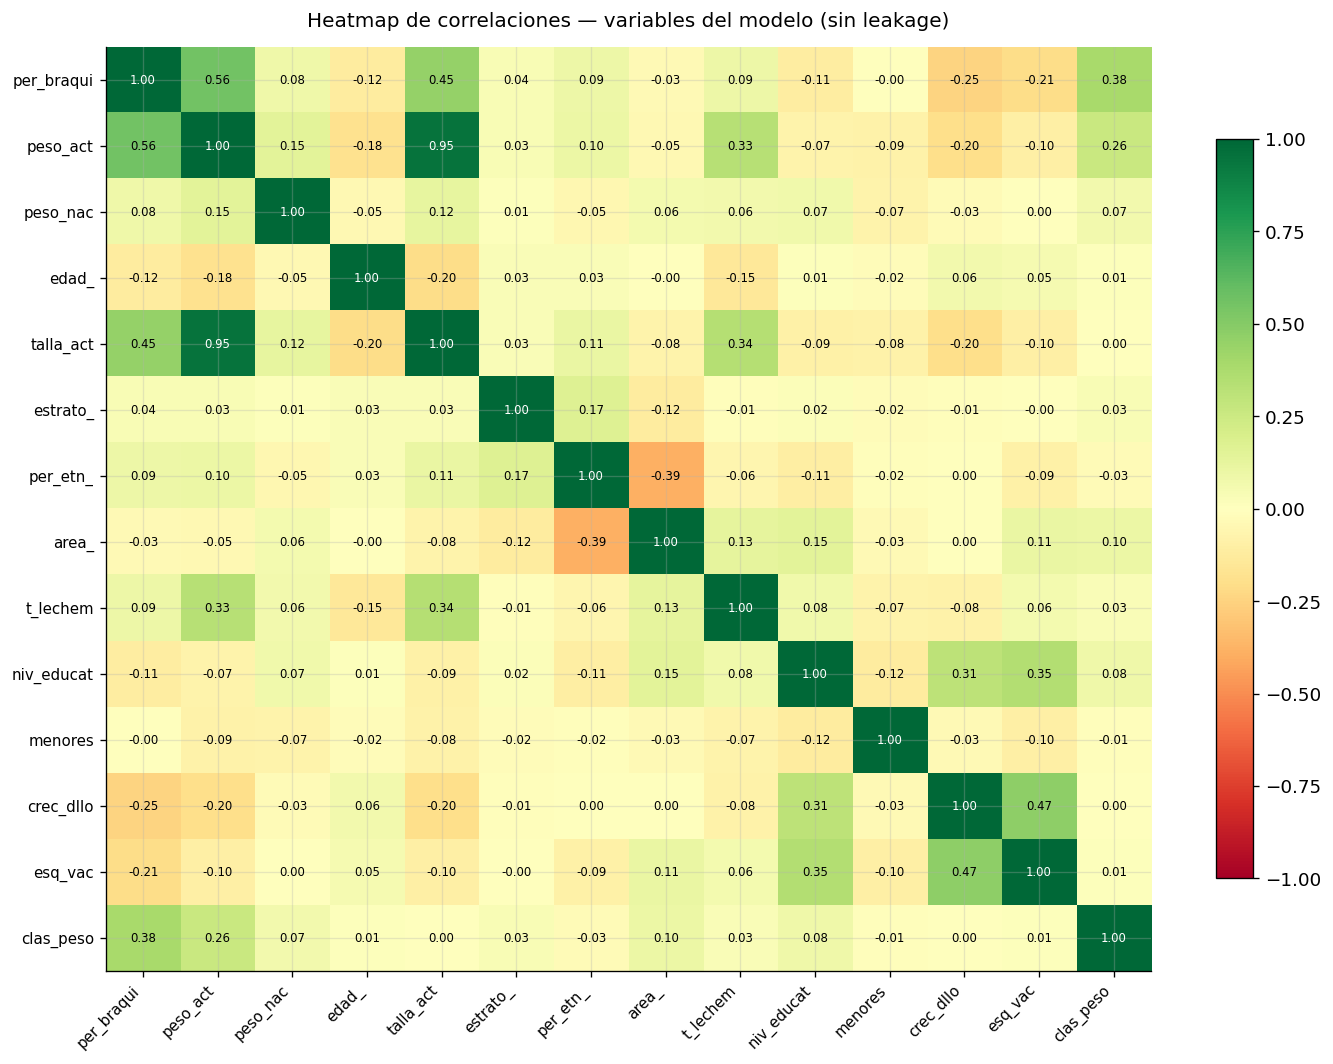

Nota: peso_act y talla_act tienen correlación ~0.95 entre sí (multicolinealidad).
En el modelado no se recomienda incluir ambas simultáneamente.


In [25]:
# Heatmap — solo variables del dataset_ml (sin leakage)
cols_heatmap = [c for c in cols_corr_todas if c not in ['zscore_pt','zscore_te','imc']] + ['clas_peso']
cols_heatmap = [c for c in cols_heatmap if c in df.columns]
corr_matrix  = df[cols_heatmap].corr()

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(cols_heatmap)))
ax.set_yticks(range(len(cols_heatmap)))
ax.set_xticklabels(cols_heatmap, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(cols_heatmap, fontsize=9)
for i in range(len(cols_heatmap)):
    for j in range(len(cols_heatmap)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                color='black' if abs(val) < 0.7 else 'white')
ax.set_title('Heatmap de correlaciones — variables del modelo (sin leakage)', fontsize=12, pad=12)
plt.tight_layout()
plt.show()
print('Nota: peso_act y talla_act tienen correlación ~0.95 entre sí (multicolinealidad).')
print('En el modelado no se recomienda incluir ambas simultáneamente.')

---
## 12. Pruebas de normalidad

**¿Por qué hacerlas?** Antes de aplicar normalización hay que probar  
si los datos tienen distribución normal. Si ya son normales, no deben normalizarse.

- **Shapiro-Wilk**: para muestras pequeñas (n ≤ 5000)  
- **Kolmogorov-Smirnov**: para muestras grandes  
- **Regla de decisión**: p-value > 0.05 → normal | p-value ≤ 0.05 → no normal → aplicar RobustScaler

In [26]:
cols_normalidad = ['per_braqui', 'peso_act', 'talla_act', 'peso_nac',
                   'edad_meses', 't_lechem', 'e_complem', 'menores']
cols_normalidad = [c for c in cols_normalidad if c in df.columns]

resultados = []
for col in cols_normalidad:
    serie = df[col].dropna()
    n     = len(serie)
    if n <= 5000:
        stat, pval = stats.shapiro(serie.sample(min(n, 5000), random_state=42))
        test = 'Shapiro-Wilk'
    else:
        stat, pval = stats.kstest(serie, 'norm', args=(serie.mean(), serie.std()))
        test = 'Kolmogorov-Smirnov'
    es_normal = 'SI' if pval > 0.05 else 'NO'
    accion    = 'No normalizar' if pval > 0.05 else 'Normalizar (RobustScaler)'
    resultados.append({'Variable': col, 'Test': test, 'n': n,
                       'Estadístico': round(stat, 4), 'p-value': round(pval, 6),
                       'Normal': es_normal, 'Acción': accion})

df_normal = pd.DataFrame(resultados)
print('Resultados de pruebas de normalidad:')
print(df_normal.to_string(index=False))
no_normales = df_normal[df_normal['Normal'] == 'NO']['Variable'].tolist()
normales    = df_normal[df_normal['Normal'] == 'SI']['Variable'].tolist()
print(f'\nVariables NO normales → aplicar RobustScaler: {no_normales}')
print(f'Variables normales    → NO normalizar        : {normales}')

Resultados de pruebas de normalidad:
  Variable         Test    n  Estadístico  p-value Normal                    Acción
per_braqui Shapiro-Wilk 2211       0.9707      0.0     NO Normalizar (RobustScaler)
  peso_act Shapiro-Wilk 2438       0.9800      0.0     NO Normalizar (RobustScaler)
 talla_act Shapiro-Wilk 2438       0.9811      0.0     NO Normalizar (RobustScaler)
  peso_nac Shapiro-Wilk 2438       0.7893      0.0     NO Normalizar (RobustScaler)
edad_meses Shapiro-Wilk 2438       0.7709      0.0     NO Normalizar (RobustScaler)
  t_lechem Shapiro-Wilk 2438       0.8735      0.0     NO Normalizar (RobustScaler)
 e_complem Shapiro-Wilk 2438       0.4247      0.0     NO Normalizar (RobustScaler)
   menores Shapiro-Wilk 2438       0.8282      0.0     NO Normalizar (RobustScaler)

Variables NO normales → aplicar RobustScaler: ['per_braqui', 'peso_act', 'talla_act', 'peso_nac', 'edad_meses', 't_lechem', 'e_complem', 'menores']
Variables normales    → NO normalizar        : []


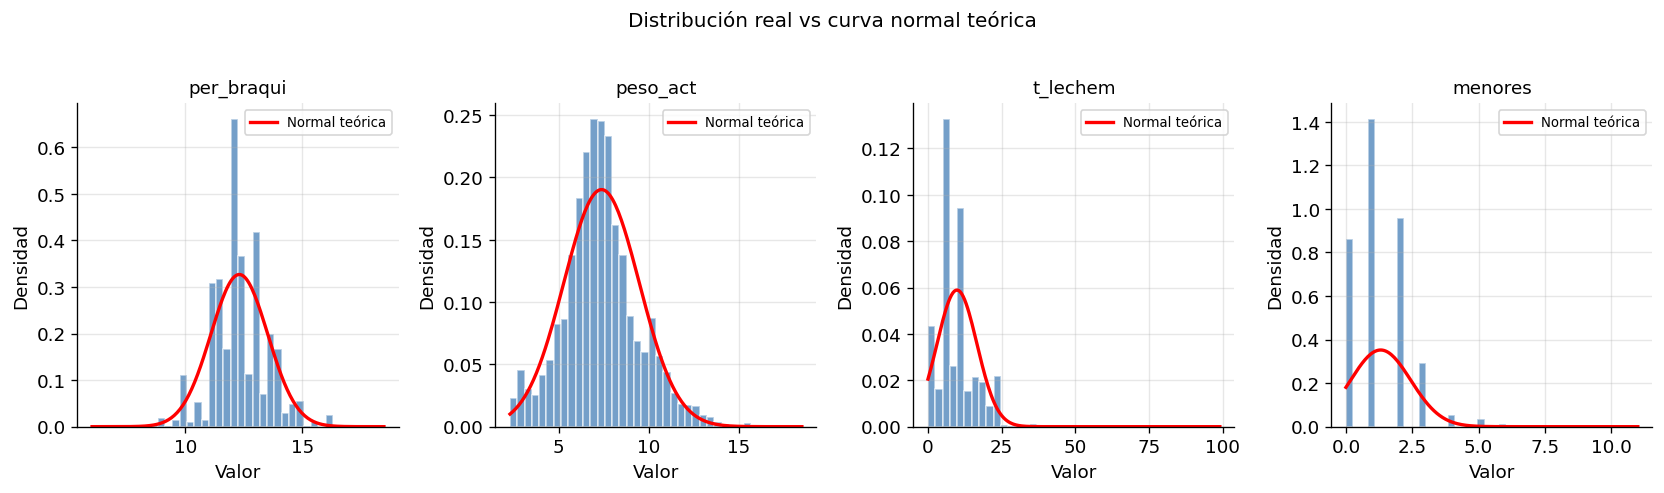

In [27]:
cols_plot = [c for c in ['per_braqui', 'peso_act', 't_lechem', 'menores'] if c in df.columns]
fig, axes = plt.subplots(1, len(cols_plot), figsize=(14, 4))
for ax, col in zip(axes, cols_plot):
    serie = df[col].dropna()
    ax.hist(serie, bins=40, color='#185fa5', alpha=0.6, density=True, edgecolor='white')
    x = np.linspace(serie.min(), serie.max(), 200)
    ax.plot(x, stats.norm.pdf(x, serie.mean(), serie.std()), 'r-', linewidth=2, label='Normal teórica')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)
fig.suptitle('Distribución real vs curva normal teórica', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 13. Análisis ANOVA — significancia estadística

**¿Por qué ANOVA?** Para determinar si las diferencias entre clases de peso son  
estadísticamente significativas para cada variable.

- **p-value < 0.05** → diferencias significativas entre clases → variable candidata al modelo  
- **F alto** → mayor diferencia entre grupos → mejor predictor potencial  

**Nota:** `zscore_pt` e `imc` se incluyen aquí solo para ilustrar el data leakage  
(F altísimo = redundancia, no poder predictivo real).

In [28]:
cols_anova = ['zscore_pt', 'imc', 'per_braqui', 'peso_act', 'talla_act',
              'peso_nac', 'edad_meses', 'zscore_te',
              't_lechem', 'niv_educat', 'menores', 'area_', 'estrato_']
cols_anova = [c for c in cols_anova if c in df.columns]

resultados_anova = []
for col in cols_anova:
    grupos = [df.loc[df['clas_peso_label'] == clase, col].dropna().values for clase in ORDEN]
    grupos = [g for g in grupos if len(g) > 1]
    if len(grupos) >= 2:
        stat, pval = stats.f_oneway(*grupos)
        sig = 'Sí (***)' if pval < 0.001 else ('Sí (*)' if pval < 0.05 else 'No')
        leakage = '⚠️ Leakage' if col in ['zscore_pt', 'zscore_te', 'imc'] else ''
        resultados_anova.append({'Variable': col, 'F-statistic': round(stat, 2),
                                  'p-value': round(pval, 6), 'Significativa': sig,
                                  'Nota': leakage})

df_anova = pd.DataFrame(resultados_anova).sort_values('F-statistic', ascending=False)
print('Resultados ANOVA — diferencias entre clases de peso:')
print(df_anova.to_string(index=False))
sig_vars = df_anova[(df_anova['Significativa'].str.startswith('Sí')) &
                    (~df_anova['Variable'].isin(['zscore_pt','zscore_te','imc']))]['Variable'].tolist()
print(f'\nVariables significativas SIN leakage → candidatas al modelo: {sig_vars}')

Resultados ANOVA — diferencias entre clases de peso:
  Variable  F-statistic  p-value Significativa       Nota
 zscore_pt      2706.80 0.000000      Sí (***) ⚠️ Leakage
       imc       848.16 0.000000      Sí (***) ⚠️ Leakage
per_braqui        87.87 0.000000      Sí (***)           
  peso_act        55.36 0.000000      Sí (***)           
 talla_act        15.70 0.000000      Sí (***)           
 zscore_te        13.08 0.000000      Sí (***) ⚠️ Leakage
  t_lechem        11.37 0.000000      Sí (***)           
niv_educat         9.83 0.000000      Sí (***)           
edad_meses         5.85 0.000022      Sí (***)           
     area_         4.77 0.000241      Sí (***)           
  peso_nac         4.50 0.000437      Sí (***)           
   menores         1.83 0.104533            No           
  estrato_         1.75 0.120417            No           

Variables significativas SIN leakage → candidatas al modelo: ['per_braqui', 'peso_act', 'talla_act', 't_lechem', 'niv_educat', 'edad_m

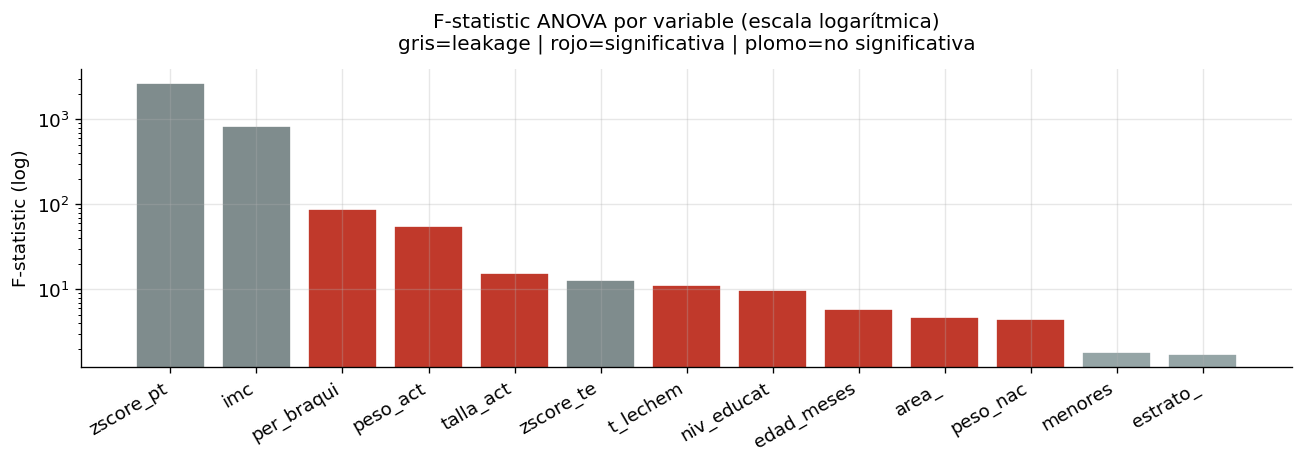

In [29]:
# Gráfico F-statistic (escala log para visualizar junto al leakage)
fig, ax = plt.subplots(figsize=(11, 4))
colores_f = []
for _, row in df_anova.iterrows():
    if row['Variable'] in ['zscore_pt', 'zscore_te', 'imc']:
        colores_f.append('#7f8c8d')  # gris = leakage
    elif row['Significativa'].startswith('Sí'):
        colores_f.append('#c0392b')
    else:
        colores_f.append('#95a5a6')

ax.bar(df_anova['Variable'], df_anova['F-statistic'], color=colores_f, edgecolor='white')
ax.set_yscale('log')
ax.set_title('F-statistic ANOVA por variable (escala logarítmica)\n'
             'gris=leakage | rojo=significativa | plomo=no significativa',
             fontsize=12, pad=12)
ax.set_ylabel('F-statistic (log)')
ax.set_xticklabels(df_anova['Variable'], rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 14. Estadísticas descriptivas detalladas por clase de peso

In [30]:
cols_desc = ['edad_meses', 'peso_nac', 'talla_nac', 'edad_ges',
             'peso_act', 'talla_act', 'per_braqui', 'imc',
             'zscore_pt', 'zscore_te', 't_lechem', 'menores']
cols_desc = [c for c in cols_desc if c in df.columns]

medias = df.groupby('clas_peso_label')[cols_desc].mean().reindex(ORDEN).round(2)
print('Medias por clase de peso:')
print(medias.to_string())

Medias por clase de peso:
                  edad_meses  peso_nac  talla_nac  edad_ges  peso_act  talla_act  per_braqui    imc  zscore_pt  zscore_te  t_lechem  menores
clas_peso_label                                                                                                                             
Desnut. severa         13.82   2709.70      47.71     38.15      6.03      69.75       11.41  12.15      -3.75      -2.92      7.79     1.37
Desnut. moderada       17.10   2779.09      48.67     38.50      7.55      74.09       12.35  13.52      -2.38      -2.65     10.43     1.29
Normal bajo            17.29   2736.84      48.00     38.36      7.50      71.65       12.45  14.35      -1.58      -3.29      8.56     1.38
Normal                 15.45   2810.19      47.64     38.82      8.04      69.96       13.36  16.04      -0.20      -3.33      9.61     1.38
Sobrepeso              18.33   2851.33      46.67     38.58      9.97      72.57       14.56  18.22       1.41      -3.64      9

In [31]:
for clase in ORDEN:
    sub = df[df['clas_peso_label'] == clase][cols_desc]
    print(f'\n{"="*60}')
    print(f'  {clase.upper()}  —  {len(sub):,} registros')
    print(f'{"="*60}')
    print(sub.describe().round(3).to_string())


  DESNUT. SEVERA  —  379 registros
       edad_meses  peso_nac  talla_nac  edad_ges  peso_act  talla_act  per_braqui      imc  zscore_pt  zscore_te  t_lechem  menores
count     379.000   379.000    161.000   379.000   379.000    379.000     328.000  379.000    379.000    379.000   379.000  379.000
mean       13.823  2709.698     47.708    38.148     6.033     69.751      11.406   12.154     -3.747     -2.917     7.786    1.375
std         9.901   389.497      3.535     2.012     1.654      9.213       1.294    0.917      0.719      1.693     5.729    1.360
min         1.000  1050.000     37.000    27.000     2.500     49.500       8.000   10.000     -5.964     -5.996     0.000    0.000
25%        10.000  2555.000     46.000    38.000     5.000     65.000      10.500   11.600     -4.091     -4.021     5.000    0.000
50%        12.000  2800.000     49.000    39.000     6.000     69.000      11.300   12.300     -3.504     -3.095     6.000    1.000
75%        12.000  2845.000     50.000  

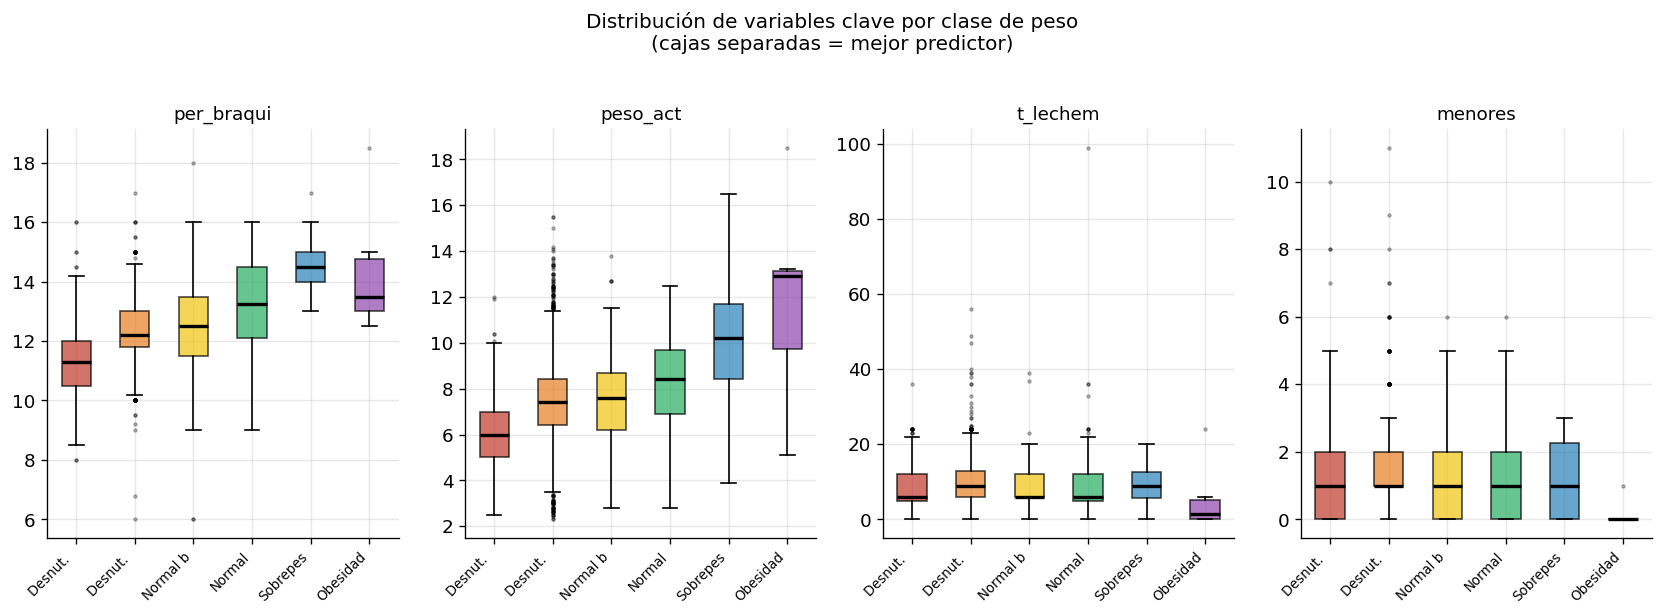

In [32]:
vars_box = [c for c in ['per_braqui', 'peso_act', 't_lechem', 'menores'] if c in df.columns]
fig, axes = plt.subplots(1, len(vars_box), figsize=(14, 5))
for ax, var in zip(axes, vars_box):
    grupos = [df.loc[df['clas_peso_label'] == c, var].dropna().values for c in ORDEN]
    bp = ax.boxplot(grupos, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=3, alpha=0.4))
    for patch, color in zip(bp['boxes'], COLORES_LISTA):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(var, fontsize=11)
    ax.set_xticks(range(1, len(ORDEN) + 1))
    ax.set_xticklabels([c[:8] for c in ORDEN], rotation=45, ha='right', fontsize=8)
fig.suptitle('Distribución de variables clave por clase de peso\n(cajas separadas = mejor predictor)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 15. Hallazgos y próximos pasos

### Resumen de variables y su relación con `clas_peso`

| Variable | Tipo | Relación | Observación |
|---|---|---|---|
| `zscore_pt` | Clínica | r≈0.91 | ⚠️ Data leakage — excluido del modelo |
| `imc` | Clínica | r≈0.79 | ⚠️ Data leakage — excluido del modelo |
| `per_braqui` | Clínica | r≈0.38 | Predictor válido más fuerte sin leakage |
| `peso_act` | Clínica | r≈0.26 | Predictor válido |
| `area_` | Geográfica | r≈0.10 | Rural disperso: mayor desnutrición |
| `niv_educat` | Socioeconómica | r≈0.08 | A mayor educación materna, menor desnutrición |
| `estrato_` | Socioeconómica | verificar | Factor protector |
| `per_etn_` | Étnica | Categórica | Indígenas: tasas más altas |
| `t_lechem` | Maternal | r≈0.03 | Baja correlación lineal pero significativa en ANOVA |
| `crec_dllo` | Seguimiento | r≈0.00 | Sin correlación lineal |
| `municipio_origen` | Geográfica | Categórica | Alta variabilidad territorial |

### Hallazgos clave
- **85%+ de los casos son desnutrición** — dataset clínico sesgado por diseño
- **La Guajira supera al Cesar en tasa de desnutrición** (~92% vs ~78%)
- **75% de casos en zona rural dispersa** — acceso limitado a servicios de salud
- **La tasa mensual se mantiene estable ~85%** entre 2024 y 2025 — sin mejora visible
- **zscore_pt promedio mensual ~-2.3** — desnutrición moderada sostenida
- **Factores maternos** (lactancia, vacunación) muestran diferencias en tasas aunque
  correlación lineal baja — relación no lineal que los árboles de decisión pueden capturar

### Sobre normalización
- Aplicar **RobustScaler solo a variables NO normales** (ver sección 12)
- Variables normales no deben normalizarse

### Sobre el desbalance de clases
- Más del 85% de los casos es desnutrición
- Requiere **SMOTE** o **`class_weight='balanced'`** en el modelado

### Próximos pasos (CRISP-DM fase 3 — Preparación de Datos)
1. Codificar variables categóricas (`municipio_origen`, `depto_origen`, `per_etn_`)
2. Aplicar normalización selectiva según resultados de sección 12
3. Evaluar multicolinealidad `peso_act` / `talla_act` antes del modelado
4. Notebook 05: selección de features + modelos de clasificación
5. Notebook 06: predicción temporal con `serie_temporal_mensual.csv`